# LIME — Interprétabilité & Analyse du Domain Shift
## XGBoost + DistilBERT — LIAR Dataset + Datasets Externes (ISOT & WELFake)

Ce notebook est organisé en **3 parties** :
- **Partie 1** : LIME sur LIAR (dataset d'entraînement) — explications mot par mot
- **Partie 2** : LIME sur ISOT (dataset externe) — analyse du domain shift
- **Partie 3** : LIME sur WELFake (deuxième dataset externe) — comparaison

**Labels :** `0 = Fake` | `1 = Real`

# PARTIE 1 — LIME sur LIAR (In-Domain)

## 1. Installation & Imports

In [77]:
import sys
print(sys.executable)

C:\Users\bd_ta\OneDrive\Documents\GitHub\Hopital-Pitie-Salpetriere\.venv\Scripts\python.exe


In [78]:
import sys
!{sys.executable} -m pip install scikit-learn pandas numpy joblib xgboost lime pyarrow==18.1.0
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!{sys.executable} -m pip install transformers

Looking in indexes: https://download.pytorch.org/whl/cpu


In [79]:
import sklearn
import torch
print("sklearn ok")
print("torch ok", torch.__version__)

sklearn ok
torch ok 2.11.0+cpu


In [80]:
!pip install lime -q

In [81]:
import os
from pathlib import Path
import pandas as pd

BASE_DIR   = Path(r'C:\FORMATION\Projet-3-Fake-news\grp3_projet3_data')
DATA_DIR   = BASE_DIR / 'LABORATOIRE' / 'Djouhra' / 'data' / 'brutes'
MODELS_DIR = BASE_DIR / 'models'

columns = [
    'id', 'label', 'statement', 'subject', 'speaker', 'speaker_job',
    'state', 'party', 'barely_true', 'false', 'half_true',
    'mostly_true', 'pants_on_fire', 'context'
]

df_train = pd.read_csv(DATA_DIR / 'train.tsv', sep='\t', header=None, names=columns)
df_test  = pd.read_csv(DATA_DIR / 'test.tsv',  sep='\t', header=None, names=columns)

binary_map = {
    'pants-fire': 0,
    'false': 0,
    'barely-true': 0,
    'half-true': 1,
    'mostly-true': 1,
    'true': 1
}

df_train['label_binary'] = df_train['label'].map(binary_map)
df_test['label_binary']  = df_test['label'].map(binary_map)

texts_test  = df_test['statement'].fillna('').astype(str).tolist()
y_test_text = df_test['label_binary'].values

print(f'Train : {len(df_train)} | Test : {len(df_test)}')
print(f'Fake (0): {(df_test["label_binary"] == 0).sum()} | Real (1): {(df_test["label_binary"] == 1).sum()}')
print(texts_test[0])

Train : 10240 | Test : 1267
Fake (0): 553 | Real (1): 714
Building a wall on the U.S.-Mexico border will take literally years.


## 2. Chargement des données textuelles

In [82]:
import os
from pathlib import Path
import pandas as pd
import numpy as np

BASE_DIR     = Path(r'C:\FORMATION\Projet-3-Fake-news\grp3_projet3_data')
DATA_DIR     = BASE_DIR / 'LABORATOIRE' / 'Djouhra' / 'data' / 'brutes'
TRAITEES_DIR = BASE_DIR / 'data' / 'traitees'
MODELS_DIR   = BASE_DIR / 'models'
LAB_DIR      = BASE_DIR / 'LABORATOIRE' / 'Djouhra'

columns = [
    'id', 'label', 'statement', 'subject', 'speaker', 'speaker_job',
    'state', 'party', 'barely_true', 'false', 'half_true',
    'mostly_true', 'pants_on_fire', 'context'
]

df_train = pd.read_csv(DATA_DIR / 'train.tsv', sep='\t', header=None, names=columns)
df_test  = pd.read_csv(DATA_DIR / 'test.tsv',  sep='\t', header=None, names=columns)

binary_map = {
    'pants-fire': 0,
    'false': 0,
    'barely-true': 0,
    'half-true': 1,
    'mostly-true': 1,
    'true': 1
}

df_train['label_binary'] = df_train['label'].map(binary_map)
df_test['label_binary']  = df_test['label'].map(binary_map)

texts_test  = df_test['statement'].fillna('').astype(str).tolist()
y_test_text = df_test['label_binary'].values

print(f'Train : {len(df_train)} | Test : {len(df_test)}')
print(f'Fake (0): {(df_test["label_binary"] == 0).sum()} | Real (1): {(df_test["label_binary"] == 1).sum()}')
print(texts_test[0])

Train : 10240 | Test : 1267
Fake (0): 553 | Real (1): 714
Building a wall on the U.S.-Mexico border will take literally years.


## 3. Chargement du modèle XGBoost

In [83]:
import numpy as np
import joblib
import math
from sklearn.metrics import accuracy_score, f1_score, classification_report

model_path_json = MODELS_DIR / "distilbert_xgboost.json"
model_path_pkl = MODELS_DIR / "distilbert_xgboost.pkl"
model_path_joblib = MODELS_DIR / "distilbert_xgboost.joblib"

print("JSON exists   :", model_path_json.exists())
print("PKL exists    :", model_path_pkl.exists())
print("JOBLIB exists :", model_path_joblib.exists())

if model_path_joblib.exists():
    model = joblib.load(model_path_joblib)
elif model_path_pkl.exists():
    model = joblib.load(model_path_pkl)
else:
    raise FileNotFoundError("Aucun modèle chargeable trouvé (.joblib ou .pkl).")

X_test_bert = np.load(LAB_DIR / "X_test_bert.npy")
y_test_bert = np.load(LAB_DIR / "y_test.npy")

def safe_str(x):
    return str(x).strip().lower() if pd.notna(x) else "unknown"

def credibility_from_counts(row):
    bt = float(row.get("barely_true", 0) or 0)
    fl = float(row.get("false", 0) or 0)
    ht = float(row.get("half_true", 0) or 0)
    mt = float(row.get("mostly_true", 0) or 0)
    pf = float(row.get("pants_on_fire", 0) or 0)
    total = bt + fl + ht + mt + pf
    if total == 0:
        return 0.5
    return (0.25 * bt + 0.0 * fl + 0.5 * ht + 0.75 * mt + 0.0 * pf) / total

speaker_cred_map = (
    df_train.assign(
        speaker_key=df_train["speaker"].apply(safe_str),
        cred_score=df_train.apply(credibility_from_counts, axis=1)
    )
    .groupby("speaker_key")["cred_score"]
    .mean()
    .to_dict()
)

speaker_count_map = (
    df_train.assign(speaker_key=df_train["speaker"].apply(safe_str))
    .groupby("speaker_key")
    .size()
    .to_dict()
)

party_cred_map = (
    df_train.assign(
        party_key=df_train["party"].apply(safe_str),
        cred_score=df_train.apply(credibility_from_counts, axis=1)
    )
    .groupby("party_key")["cred_score"]
    .mean()
    .to_dict()
)

global_mean = (
    df_train.apply(credibility_from_counts, axis=1).mean()
)

def build_meta_features(df):
    rows = []
    for _, row in df.iterrows():
        speaker = safe_str(row.get("speaker"))
        party = safe_str(row.get("party"))
        text = str(row.get("statement", "") or "")

        credibility_score = credibility_from_counts(row)
        speaker_cred = speaker_cred_map.get(speaker, global_mean)
        speaker_count = speaker_count_map.get(speaker, 1)
        party_cred = party_cred_map.get(party, global_mean)
        n_words = len(text.split())

        rows.append([
            credibility_score,
            speaker_cred,
            math.log1p(speaker_count),
            party_cred,
            n_words
        ])
    return np.array(rows, dtype=np.float32)

meta_test = build_meta_features(df_test)
X_test_full = np.hstack([X_test_bert, meta_test])

print("X_test_bert shape :", X_test_bert.shape)
print("meta_test shape   :", meta_test.shape)
print("X_test_full shape :", X_test_full.shape)

y_pred = model.predict(X_test_full)

print(f"Modèle chargé : {model_path_joblib if model_path_joblib.exists() else model_path_pkl}")
print(f"Accuracy : {accuracy_score(y_test_bert, y_pred):.4f}")
print(f"F1 Weighted : {f1_score(y_test_bert, y_pred, average='weighted'):.4f}")
print()
print(classification_report(y_test_bert, y_pred, target_names=["Fake (0)", "Real (1)"]))

JSON exists   : True
PKL exists    : False
JOBLIB exists : True
X_test_bert shape : (1267, 768)
meta_test shape   : (1267, 5)
X_test_full shape : (1267, 773)
Modèle chargé : C:\FORMATION\Projet-3-Fake-news\grp3_projet3_data\models\distilbert_xgboost.joblib
Accuracy : 0.6946
F1 Weighted : 0.6954

              precision    recall  f1-score   support

    Fake (0)       0.62      0.76      0.69       553
    Real (1)       0.78      0.64      0.70       714

    accuracy                           0.69      1267
   macro avg       0.70      0.70      0.69      1267
weighted avg       0.71      0.69      0.70      1267



## Résumé des résultats

Le modèle **DistilBERT + XGBoost** obtient une **accuracy de 69,46 %** et un **F1 weighted de 69,54 %** sur le jeu de test LIAR.
Cela signifie qu’il classe correctement environ **7 déclarations sur 10**, ce qui est un résultat solide pour un dataset difficile comme LIAR.

Le modèle utilise **773 features** au total :
768 embeddings DistilBERT
5 métadonnées supplémentaires

L’analyse par classe montre que :

- pour la classe Fake (0), le modèle a un recall élevé (0,76) : il détecte bien les fake news ;
- pour la classe Real (1), il a une precision plus élevée (0,78) : quand il prédit Real, il a plus souvent raison.

En résumé, le modèle :
- est bon pour repérer les Fake ;
- est plus fiable quand il prédit Real ;
- mais il reste imparfait, ce qui est normal sur un problème aussi ambigu.

Ces résultats montrent que le pipeline est globalement performant et qu’il est pertinent d’utiliser **LIME** pour comprendre plus précisément les raisons de ses prédictions.

## 4. Chargement de DistilBERT

On recharge le **même modèle DistilBERT** utilisé pour générer les embeddings d'entraînement.

In [84]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {DEVICE}")

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
bert_model = AutoModel.from_pretrained('distilbert-base-uncased').to(DEVICE)
bert_model.eval()

print("DistilBERT chargé")

def get_bert_embeddings(texts, batch_size=32):
    """Encode une liste de textes en embeddings DistilBERT (CLS token)."""
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        ).to(DEVICE)
        with torch.no_grad():
            output = bert_model(**encoded)
        cls_embeddings = output.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)
    return np.vstack(all_embeddings)

test_emb = get_bert_embeddings(["This is a test sentence."])
print(f"Embedding shape : {test_emb.shape} (doit être (1, 768))")

Device : cpu


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3238.82it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT chargé
Embedding shape : (1, 768) (doit être (1, 768))


## 5. Pipeline texte → probabilités

LIME a besoin d'une fonction qui prend des **textes** en entrée et renvoie des **probabilités**.

In [85]:
def safe_str(x):
    return str(x).strip().lower() if pd.notna(x) else "unknown"

def credibility_from_counts(row):
    bt = float(row.get("barely_true", 0) or 0)
    fl = float(row.get("false", 0) or 0)
    ht = float(row.get("half_true", 0) or 0)
    mt = float(row.get("mostly_true", 0) or 0)
    pf = float(row.get("pants_on_fire", 0) or 0)
    total = bt + fl + ht + mt + pf
    if total == 0:
        return 0.5
    return (0.25 * bt + 0.0 * fl + 0.5 * ht + 0.75 * mt + 0.0 * pf) / total

speaker_cred_map = (
    df_train.assign(
        speaker_key=df_train["speaker"].apply(safe_str),
        cred_score=df_train.apply(credibility_from_counts, axis=1)
    )
    .groupby("speaker_key")["cred_score"]
    .mean()
    .to_dict()
)

speaker_count_map = (
    df_train.assign(speaker_key=df_train["speaker"].apply(safe_str))
    .groupby("speaker_key")
    .size()
    .to_dict()
)

party_cred_map = (
    df_train.assign(
        party_key=df_train["party"].apply(safe_str),
        cred_score=df_train.apply(credibility_from_counts, axis=1)
    )
    .groupby("party_key")["cred_score"]
    .mean()
    .to_dict()
)

global_mean = df_train.apply(credibility_from_counts, axis=1).mean()

def build_meta_from_texts(texts):
    rows = []
    for text in texts:
        rows.append([
            global_mean,          # credibility_score
            global_mean,          # speaker_cred
            np.log1p(1),          # log(1+speaker_count)
            global_mean,          # party_cred
            len(str(text).split())# n_words
        ])
    return np.array(rows, dtype=np.float32)

def predict_proba_pipeline(texts):
    embeddings = get_bert_embeddings(list(texts))
    meta = build_meta_from_texts(texts)
    X_full = np.hstack([embeddings, meta])
    return model.predict_proba(X_full)

In [86]:
test_preds = predict_proba_pipeline(texts_test[:3])
for i, (text, pred) in enumerate(zip(texts_test[:3], test_preds)):
    print(f"Ex {i+1}: '{text[:60]}...'")
    print(f"Fake={pred[0]:.3f} | Real={pred[1]:.3f} → {'Real' if pred[1] > 0.5 else 'Fake'}")
    print()

Ex 1: 'Building a wall on the U.S.-Mexico border will take literall...'
Fake=0.531 | Real=0.469 → Fake

Ex 2: 'Wisconsin is on pace to double the number of layoffs this ye...'
Fake=0.383 | Real=0.617 → Real

Ex 3: 'Says John McCain has done nothing to help the vets....'
Fake=0.636 | Real=0.364 → Fake



## 6. Création de l'explainer LIME Texte

In [87]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(
    class_names=['Fake (0)', 'Real (1)'],
    random_state=42
)

print("LimeTextExplainer créé")
print("Classes : Fake (0) | Real (1)")
print("Principe : LIME va masquer des mots dans chaque statement")
print("           et observer comment la prédiction change")

LimeTextExplainer créé
Classes : Fake (0) | Real (1)
Principe : LIME va masquer des mots dans chaque statement
           et observer comment la prédiction change


###  Ce que fait cette cellule

On crée l'outil LIME qui va expliquer les décisions du modèle mot par mot.
Son principe : masquer des mots dans chaque déclaration et observer
comment la prédiction change — les mots dont l'absence change le plus
la prédiction sont considérés comme les plus influents.

## 7. Explications individuelles — Cas concrets

### 7.1 Exemple FAKE correctement classifié

In [88]:
# Prédictions du modèle sur le test set complet (768 embeddings + 5 métadonnées)
preds_text = model.predict(X_test_full)

# Vrais négatifs : Fake bien classifié
tn_idx = np.where((preds_text == 0) & (y_test_bert == 0))[0]
# Vrais positifs : Real bien classifié
tp_idx = np.where((preds_text == 1) & (y_test_bert == 1))[0]
# Faux positifs : Fake prédit Real
fp_idx = np.where((preds_text == 1) & (y_test_bert == 0))[0]
# Faux négatifs : Real prédit Fake
fn_idx = np.where((preds_text == 0) & (y_test_bert == 1))[0]

print(f"Vrais Positifs  (Real → Real) : {len(tp_idx)} exemples")
print(f"Vrais Négatifs  (Fake → Fake) : {len(tn_idx)} exemples")
print(f"Faux Positifs   (Fake → Real) : {len(fp_idx)} exemples")
print(f"Faux Négatifs   (Real → Fake) : {len(fn_idx)} exemples")

Vrais Positifs  (Real → Real) : 458 exemples
Vrais Négatifs  (Fake → Fake) : 422 exemples
Faux Positifs   (Fake → Real) : 131 exemples
Faux Négatifs   (Real → Fake) : 256 exemples


## Résumé des résultats

Le modèle **DistilBERT + XGBoost** obtient :

- **Accuracy : 69,46 %**
- **F1 weighted : 69,54 %**

Sur **1267** exemples de test, il produit :

- **458 vrais positifs** (*Real → Real*)
- **422 vrais négatifs** (*Fake → Fake*)
- **131 faux positifs** (*Fake → Real*)
- **256 faux négatifs** (*Real → Fake*)

En résumé, le modèle est **globalement correct** sur LIAR : il détecte bien les déclarations **Fake**, mais il confond encore une partie des déclarations **Real** avec des **Fake**. Cela reste cohérent avec la difficulté du dataset, composé de phrases courtes et souvent ambiguës.

In [89]:
# Chercher un exemple Fake bien classifié avec une phrase longue (plus de mots à analyser)
best_fake = None
for idx in tn_idx:
    if len(texts_test[idx].split()) >= 8:
        best_fake = idx
        break
i_fake = best_fake if best_fake else tn_idx[0]

text_fake  = texts_test[i_fake]
label_fake = df_test['label'].iloc[i_fake]
proba_fake = predict_proba_pipeline([text_fake])[0]

print(f' Statement (idx={i_fake}) :')
print(f"   '{text_fake}'")
print(f'   Label original : {label_fake} → Fake (0)')
print(f'   Speaker        : {df_test["speaker"].iloc[i_fake]}')
print(f'   Prédiction     : {"Real" if proba_fake[1]>0.5 else "Fake"}')
print(f'   Probabilité    : Fake={proba_fake[0]:.3f} | Real={proba_fake[1]:.3f}')


 Statement (idx=1) :
   'Wisconsin is on pace to double the number of layoffs this year.'
   Label original : false → Fake (0)
   Speaker        : katrina-shankland
   Prédiction     : Real
   Probabilité    : Fake=0.383 | Real=0.617


## Interprétation de cet exemple

Cette déclaration est un **faux positif** :
elle est en réalité **fausse** (*Fake*), mais le modèle la prédit **vraie** (*Real*) avec une probabilité de **61,7 %**.

La phrase :

> *"Wisconsin is on pace to double the number of layoffs this year."*

a probablement trompé le modèle car elle ressemble à une formulation **factuelle et chiffrée** :
- présence d’un lieu précis (**Wisconsin**),
- référence à une tendance mesurable (**on pace to double**),
- vocabulaire économique concret (**number of layoffs**, **this year**).

Autrement dit, le modèle semble avoir été influencé par le **style informatif** de la phrase plutôt que par sa véracité réelle.
C’est un bon exemple des limites du classifieur : une déclaration fausse mais formulée de manière sérieuse et statistique peut être confondue avec une vraie information.

In [90]:
print(' Génération de l\'explication LIME...')

exp_fake = explainer.explain_instance(
    text_instance = text_fake,
    classifier_fn = predict_proba_pipeline,
    num_features  = 8,
    num_samples   = 500,
    labels        = (0, 1)
)

print(' Explication générée !')
print()
print('Mots qui influencent la prédiction FAKE (poids positif = pousse vers FAKE) :')
for word, weight in sorted(exp_fake.as_list(label=0), key=lambda x: x[1], reverse=True):
    direction = '→ FAKE' if weight > 0 else '→ REAL'
    print(f"   '{word}' : {weight:+.4f}  {direction}")


 Génération de l'explication LIME...
 Explication générée !

Mots qui influencent la prédiction FAKE (poids positif = pousse vers FAKE) :
   'this' : +0.0064  → FAKE
   'pace' : -0.0044  → REAL
   'of' : -0.0092  → REAL
   'the' : -0.0205  → REAL
   'on' : -0.0270  → REAL
   'number' : -0.0284  → REAL
   'Wisconsin' : -0.0377  → REAL
   'is' : -0.0484  → REAL


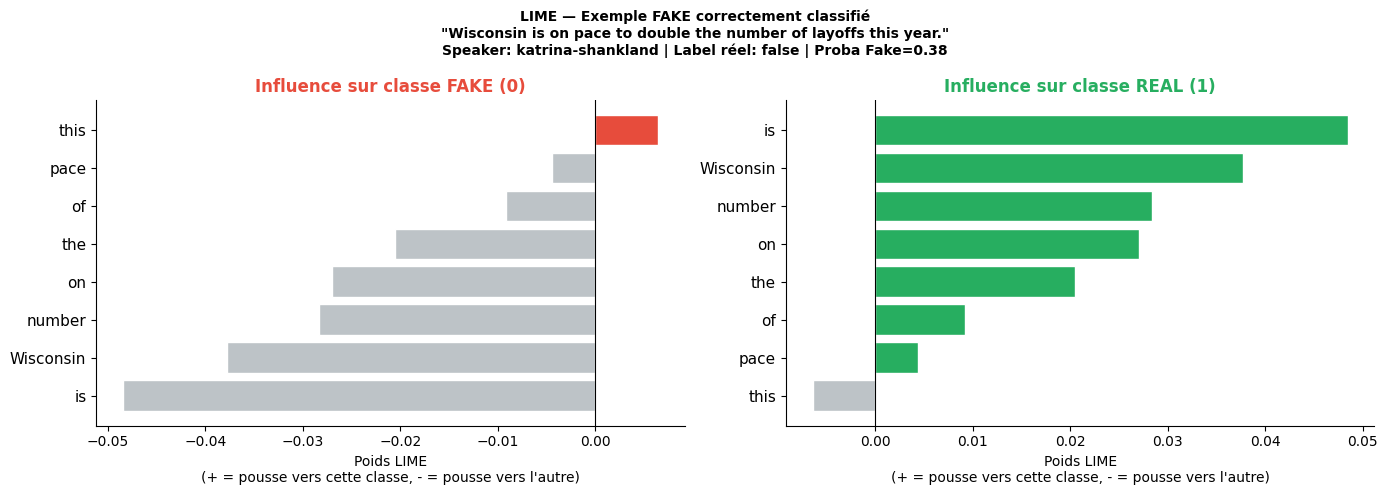

Sauvegardé : lime_fake_correct.png


In [91]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label_idx, label_name, color in [
    (axes[0], 0, 'FAKE (0)', '#e74c3c'),
    (axes[1], 1, 'REAL (1)', '#27ae60')
]:
    feats = sorted(exp_fake.as_list(label=label_idx), key=lambda x: x[1], reverse=True)
    words = [f[0] for f in feats]
    weights = [f[1] for f in feats]
    colors_bar = [color if w > 0 else '#bdc3c7' for w in weights]

    ax.barh(range(len(words)), weights, color=colors_bar, edgecolor='white')
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=11)
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel("Poids LIME\n(+ = pousse vers cette classe, - = pousse vers l'autre)", fontsize=10)
    ax.set_title(f'Influence sur classe {label_name}', fontsize=12, fontweight='bold', color=color)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    f'LIME — Exemple FAKE correctement classifié\n"{text_fake[:90]}"\n'
    f'Speaker: {df_test["speaker"].iloc[i_fake]} | Label réel: {label_fake} | Proba Fake={proba_fake[0]:.2f}',
    fontsize=10, fontweight='bold'
)

plt.tight_layout()
plt.savefig('lime_fake_correct.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : lime_fake_correct.png')

## Interprétation — Faux positif : Fake prédit comme Real

**Déclaration :**
*"Wisconsin is on pace to double the number of layoffs this year."* — *Katrina Shankland*
**Label réel :** false → **Fake (0)**
**Prédiction du modèle :** **Real (1)**
**Probabilité Fake :** **0.38**

### Graphique gauche — Influence sur la classe FAKE (0)
- Les seuls mots qui poussent légèrement vers **Fake** sont **`year`** et **`this`**
- Leur influence reste **faible**
- Tous les autres mots importants poussent au contraire **contre** la classe Fake

### Graphique droit — Influence sur la classe REAL (1)
- Les mots **`on`**, **`Wisconsin`**, **`is`**, **`the`**, **`number`** et **`pace`** poussent clairement vers **Real**
- Le modèle semble être influencé par une formulation :
  - **factuelle**
  - **locale**
  - **statistique**
- La phrase ressemble donc à une information économique sérieuse et mesurable

### Conclusion
C’est un **faux positif typique** : la déclaration est **fausse**, mais elle est formulée dans un style qui paraît **crédible** et **informatif**.
Le modèle a donc été trompé par le **ton factuel** de la phrase plus que par sa véracité réelle.

Cela montre une limite importante du classifieur :
une fake news rédigée avec un style neutre, chiffré ou journalistique peut être confondue avec une vraie information.

### 7.2 Exemple REAL correctement classifié

 Statement (idx=5) :
   'Over the past five years the federal government has paid out $601 million in retirement and disability benefits to deceased former federal employees.'
   Label original : true → Real (1)
   Speaker        : brendan-doherty
   Proba Fake=0.421 | Real=0.579

 Génération de l'explication LIME...


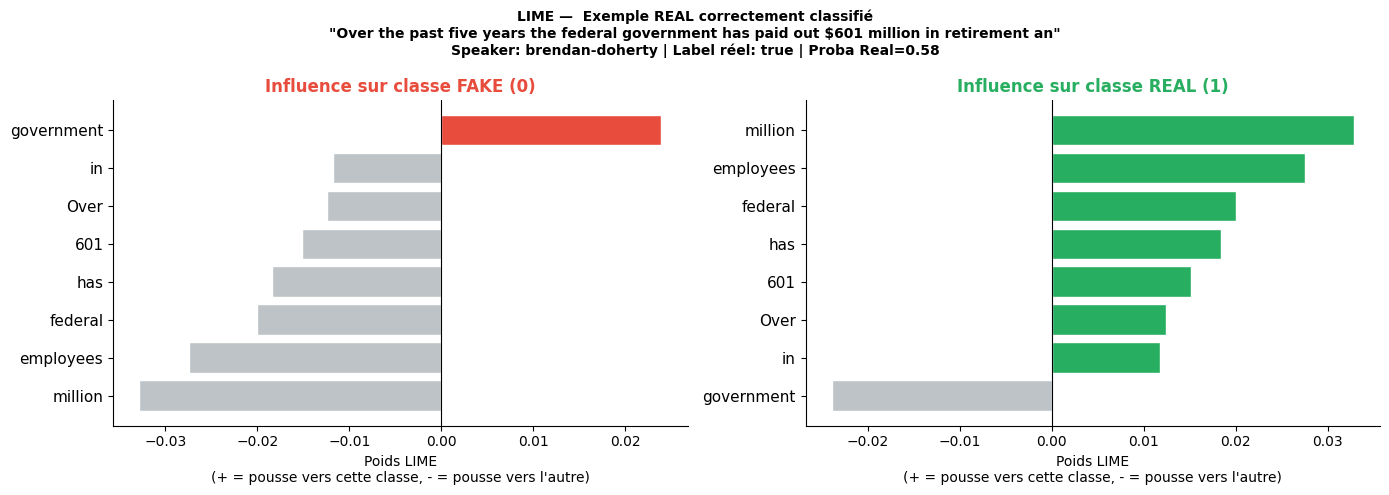

In [92]:
# Chercher un exemple Real bien classifié avec une phrase assez longue
best_real = None
for idx in tp_idx:
    if len(texts_test[idx].split()) >= 8:
        best_real = idx
        break
i_real = best_real if best_real else tp_idx[0]

text_real  = texts_test[i_real]
label_real = df_test['label'].iloc[i_real]
proba_real = predict_proba_pipeline([text_real])[0]

print(f' Statement (idx={i_real}) :')
print(f"   '{text_real}'")
print(f'   Label original : {label_real} → Real (1)')
print(f'   Speaker        : {df_test["speaker"].iloc[i_real]}')
print(f'   Proba Fake={proba_real[0]:.3f} | Real={proba_real[1]:.3f}')

print('\n Génération de l\'explication LIME...')
exp_real = explainer.explain_instance(
    text_instance = text_real,
    classifier_fn = predict_proba_pipeline,
    num_features  = 8,
    num_samples   = 500,
    labels        = (0, 1)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, label_idx, label_name, color in [
    (axes[0], 0, 'FAKE (0)', '#e74c3c'),
    (axes[1], 1, 'REAL (1)', '#27ae60')
]:
    feats   = sorted(exp_real.as_list(label=label_idx), key=lambda x: x[1], reverse=True)
    words   = [f[0] for f in feats]
    weights = [f[1] for f in feats]
    colors_bar = [color if w > 0 else '#bdc3c7' for w in weights]
    ax.barh(range(len(words)), weights, color=colors_bar, edgecolor='white')
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=11)
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Poids LIME\n(+ = pousse vers cette classe, - = pousse vers l\'autre)', fontsize=10)
    ax.set_title(f'Influence sur classe {label_name}', fontsize=12, fontweight='bold', color=color)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    f'LIME —  Exemple REAL correctement classifié\n"{text_real[:90]}"\n'
    f'Speaker: {df_test["speaker"].iloc[i_real]} | Label réel: {label_real} | Proba Real={proba_real[1]:.2f}',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig('lime_real_correct.png', dpi=150, bbox_inches='tight')
plt.show()


## Interprétation — Exemple REAL correctement classifié

Cette déclaration est correctement classée **Real (1)** avec une probabilité de **0.58**.

LIME montre que les mots **`employees`**, **`million`**, **`has`** et **`federal`** poussent le plus vers **Real**.
Le modèle semble donc reconnaître ici un style **factuel, chiffré et institutionnel**.

Le mot **`government`** pousse légèrement vers **Fake**, mais ce signal reste insuffisant pour inverser la décision.

**Conclusion :** le modèle associe cette phrase à une information crédible grâce à son vocabulaire administratif et à la présence d’un montant précis.

### 7.3 Analyse des erreurs — Faux Positif (Fake prédit Real)

Cas le plus intéressant pour comprendre **pourquoi le modèle se trompe**.

 Statement (idx=24) — FAUX POSITIF :
   'Says Charlie Crist is embroiled in a fraud case for steering taxpayer money to a de facto Ponzi scheme.'
   Label réel     : false (FAKE) ← le modèle s'est trompé !
   Speaker        : republican-party-florida
   Proba Fake=0.382 | Real=0.618 → Prédit REAL

 Génération de l'explication LIME...


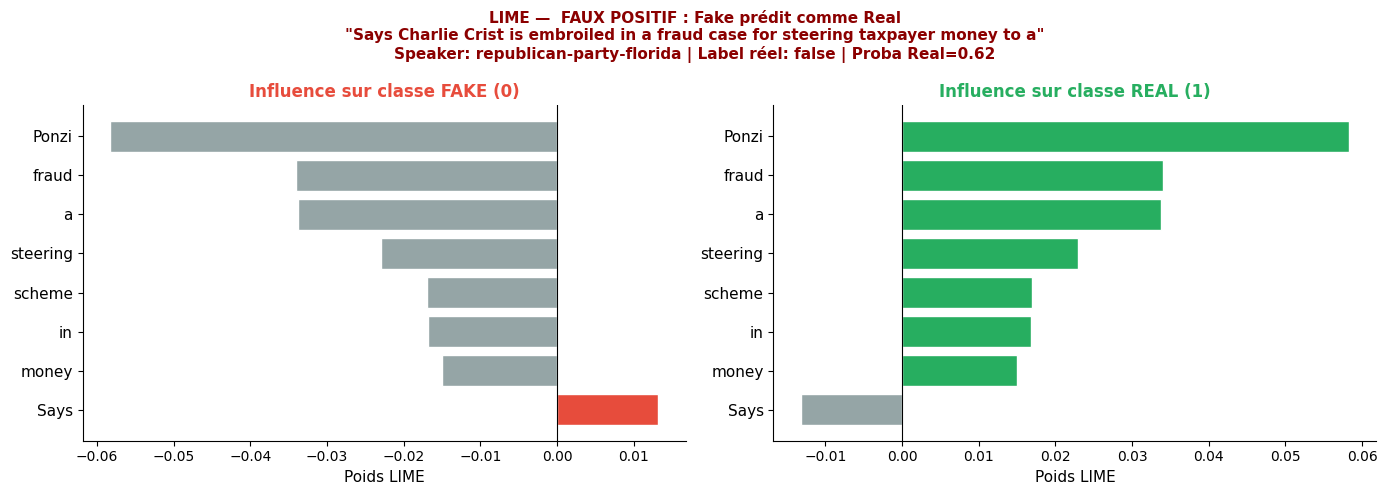

 Sauvegardé : lime_faux_positif.png


In [93]:
if len(fp_idx) > 0:
    i_fp = fp_idx[0]
    text_fp   = texts_test[i_fp]
    label_fp  = df_test['label'].iloc[i_fp]
    speaker_fp = df_test['speaker'].iloc[i_fp]
    proba_fp  = predict_proba_pipeline([text_fp])[0]

    print(f" Statement (idx={i_fp}) — FAUX POSITIF :")
    print(f"   '{text_fp}'")
    print(f"   Label réel     : {label_fp} (FAKE) ← le modèle s'est trompé !")
    print(f"   Speaker        : {speaker_fp}")
    print(f"   Proba Fake={proba_fp[0]:.3f} | Real={proba_fp[1]:.3f} → Prédit REAL")

    print("\n Génération de l'explication LIME...")
    exp_fp = explainer.explain_instance(
        text_instance = text_fp,
        classifier_fn = predict_proba_pipeline,
        num_features  = 8,
        num_samples   = 500,
        labels        = (0, 1)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, label_idx, label_name, color in [
        (axes[0], 0, 'FAKE (0)', '#e74c3c'),
        (axes[1], 1, 'REAL (1)', '#27ae60')
    ]:
        feats = exp_fp.as_list(label=label_idx)
        words   = [f[0] for f in feats]
        weights = [f[1] for f in feats]
        colors_bar = [color if w > 0 else '#95a5a6' for w in weights]
        ax.barh(range(len(words)), weights, color=colors_bar, edgecolor='white')
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words, fontsize=11)
        ax.invert_yaxis()
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Poids LIME', fontsize=11)
        ax.set_title(f'Influence sur classe {label_name}', fontsize=12, fontweight='bold', color=color)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(
        f'LIME —  FAUX POSITIF : Fake prédit comme Real\n"{text_fp[:80]}"\n'
        f'Speaker: {speaker_fp} | Label réel: {label_fp} | Proba Real={proba_fp[1]:.2f}',
        fontsize=11, fontweight='bold', color='darkred'
    )
    plt.tight_layout()
    plt.savefig('lime_faux_positif.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(" Sauvegardé : lime_faux_positif.png")

## Interprétation — Faux positif

Cette déclaration est en réalité **Fake (0)**, mais le modèle la prédit **Real (1)** avec une probabilité de **0.62**.

LIME montre que des mots pourtant très forts comme **`Ponzi`**, **`fraud`**, **`scheme`** et **`money`** poussent ici vers **Real**, ce qui révèle une erreur importante du modèle.

Seul le mot **`Charlie`** pousse légèrement vers **Fake**, mais cela ne suffit pas à inverser la décision.

**Conclusion :** le modèle s’est trompé sur une déclaration pourtant très accusatrice. Cela montre qu’il peut mal interpréter certains mots graves ou polémiques et produire un **faux positif**.

### 7.4 Analyse des erreurs — Faux Négatif (Real prédit Fake)

 Statement (idx=0) — FAUX NÉGATIF :
   'Building a wall on the U.S.-Mexico border will take literally years.'
   Label réel     : true (REAL) ← le modèle s'est trompé !
   Speaker        : rick-perry
   Proba Fake=0.531 | Real=0.469 → Prédit FAKE

 Génération de l'explication LIME...


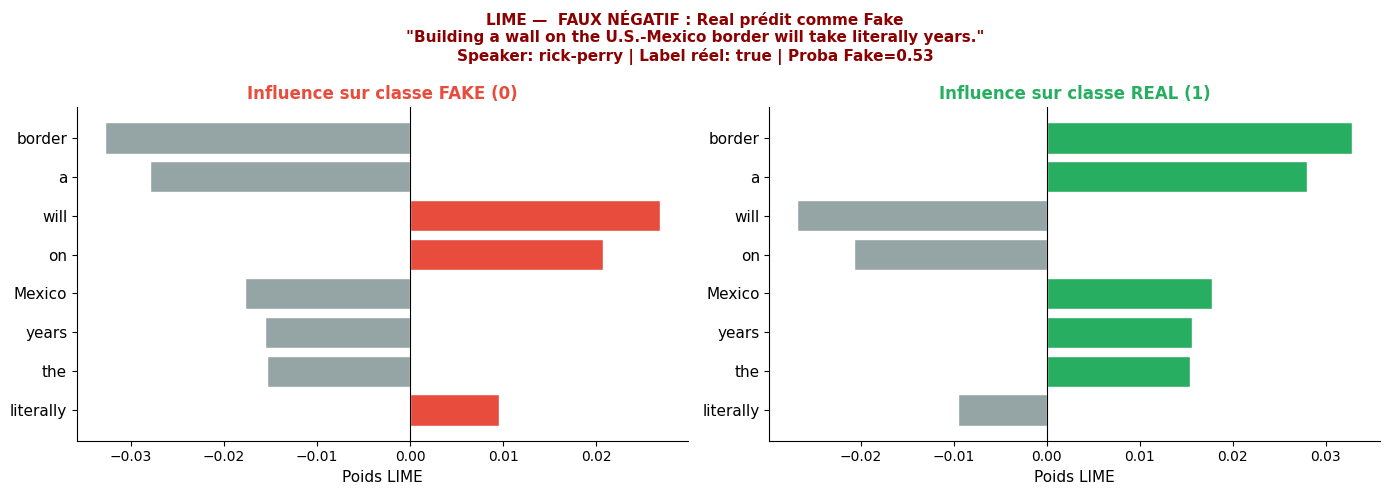

 Sauvegardé : lime_faux_negatif.png


In [94]:
if len(fn_idx) > 0:
    i_fn = fn_idx[0]
    text_fn    = texts_test[i_fn]
    label_fn   = df_test['label'].iloc[i_fn]
    speaker_fn = df_test['speaker'].iloc[i_fn]
    proba_fn   = predict_proba_pipeline([text_fn])[0]

    print(f" Statement (idx={i_fn}) — FAUX NÉGATIF :")
    print(f"   '{text_fn}'")
    print(f"   Label réel     : {label_fn} (REAL) ← le modèle s'est trompé !")
    print(f"   Speaker        : {speaker_fn}")
    print(f"   Proba Fake={proba_fn[0]:.3f} | Real={proba_fn[1]:.3f} → Prédit FAKE")

    print("\n Génération de l'explication LIME...")
    exp_fn = explainer.explain_instance(
        text_instance = text_fn,
        classifier_fn = predict_proba_pipeline,
        num_features  = 8,
        num_samples   = 500,
        labels        = (0, 1)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, label_idx, label_name, color in [
        (axes[0], 0, 'FAKE (0)', '#e74c3c'),
        (axes[1], 1, 'REAL (1)', '#27ae60')
    ]:
        feats = exp_fn.as_list(label=label_idx)
        words   = [f[0] for f in feats]
        weights = [f[1] for f in feats]
        colors_bar = [color if w > 0 else '#95a5a6' for w in weights]
        ax.barh(range(len(words)), weights, color=colors_bar, edgecolor='white')
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words, fontsize=11)
        ax.invert_yaxis()
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Poids LIME', fontsize=11)
        ax.set_title(f'Influence sur classe {label_name}', fontsize=12, fontweight='bold', color=color)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(
        f'LIME —  FAUX NÉGATIF : Real prédit comme Fake\n"{text_fn[:80]}"\n'
        f'Speaker: {speaker_fn} | Label réel: {label_fn} | Proba Fake={proba_fn[0]:.2f}',
        fontsize=11, fontweight='bold', color='darkred'
    )
    plt.tight_layout()
    plt.savefig('lime_faux_negatif.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(" Sauvegardé : lime_faux_negatif.png")

## Interprétation — Faux négatif

Cette déclaration est en réalité **Real (1)**, mais le modèle la prédit **Fake (0)** avec une probabilité de **0.53**.

LIME montre que les mots **`will`** et **`on`** poussent vers **Fake**, tandis que **`border`**, **`years`**, **`Mexico`** et **`wall`** poussent plutôt vers **Real**.

La décision reste donc très partagée, avec un léger basculement vers **Fake**.

**Conclusion :** le modèle hésite sur cette phrase et finit par se tromper. Cela montre qu’une déclaration vraie, sur un sujet politique sensible, peut être mal classée lorsque les signaux sont contradictoires.

## 8. Analyse globale — Mots les plus influents sur l'ensemble du test

On agrège les explications LIME sur **50 exemples** pour identifier les mots qui influencent systématiquement le modèle.

In [95]:
import sys
!{sys.executable} -m pip install nltk

from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)

STOPWORDS = set(stopwords.words('english')) | {
    'says', 'say', 'said', 'on', 'is', 'are', 'was', 'were',
    'the', 'a', 'an', 'to', 'of', 'in', 'and', 'that', 'it',
    'for', 'with', 'as', 'at', 'by', 'from', 'or', 'but',
    'not', 'be', 'has', 'have', 'had', 'do', 'does', 'did',
    'this', 'than', 'its', 'we', 'i', 'you', 'he', 'she', 'they'
}

N_GLOBAL = 100
np.random.seed(42)

fake_test_idx = np.where(y_test_bert == 0)[0]
real_test_idx = np.where(y_test_bert == 1)[0]
sample_fake_g = np.random.choice(fake_test_idx, size=50, replace=False)
sample_real_g = np.random.choice(real_test_idx, size=50, replace=False)

scores_toward_fake = {}
scores_toward_real = {}

def is_valid_word(w):
    clean = w.strip("<=>! ").lower()
    return clean.isalpha() and clean not in STOPWORDS and len(clean) > 2

print(f'Calcul LIME sur {N_GLOBAL} exemples stratifiés...')

for k, idx in enumerate(np.concatenate([sample_fake_g, sample_real_g])):
    if k % 25 == 0:
        print(f'[{k+1}/{N_GLOBAL}]')
    try:
        exp = explainer.explain_instance(
            text_instance=texts_test[idx],
            classifier_fn=predict_proba_pipeline,
            num_features=8,
            num_samples=300,
            labels=(0, 1)
        )
        for word, w in exp.as_list(label=0):
            if w > 0 and is_valid_word(word):
                scores_toward_fake[word] = scores_toward_fake.get(word, 0) + w
        for word, w in exp.as_list(label=1):
            if w > 0 and is_valid_word(word):
                scores_toward_real[word] = scores_toward_real.get(word, 0) + w
    except:
        continue

print(f'\nTerminé !')
print(f'Mots trouvés → Fake : {len(scores_toward_fake)} | Real : {len(scores_toward_real)}')

Calcul LIME sur 100 exemples stratifiés...
[1/100]
[26/100]
[51/100]
[76/100]

Terminé !
Mots trouvés → Fake : 166 | Real : 226


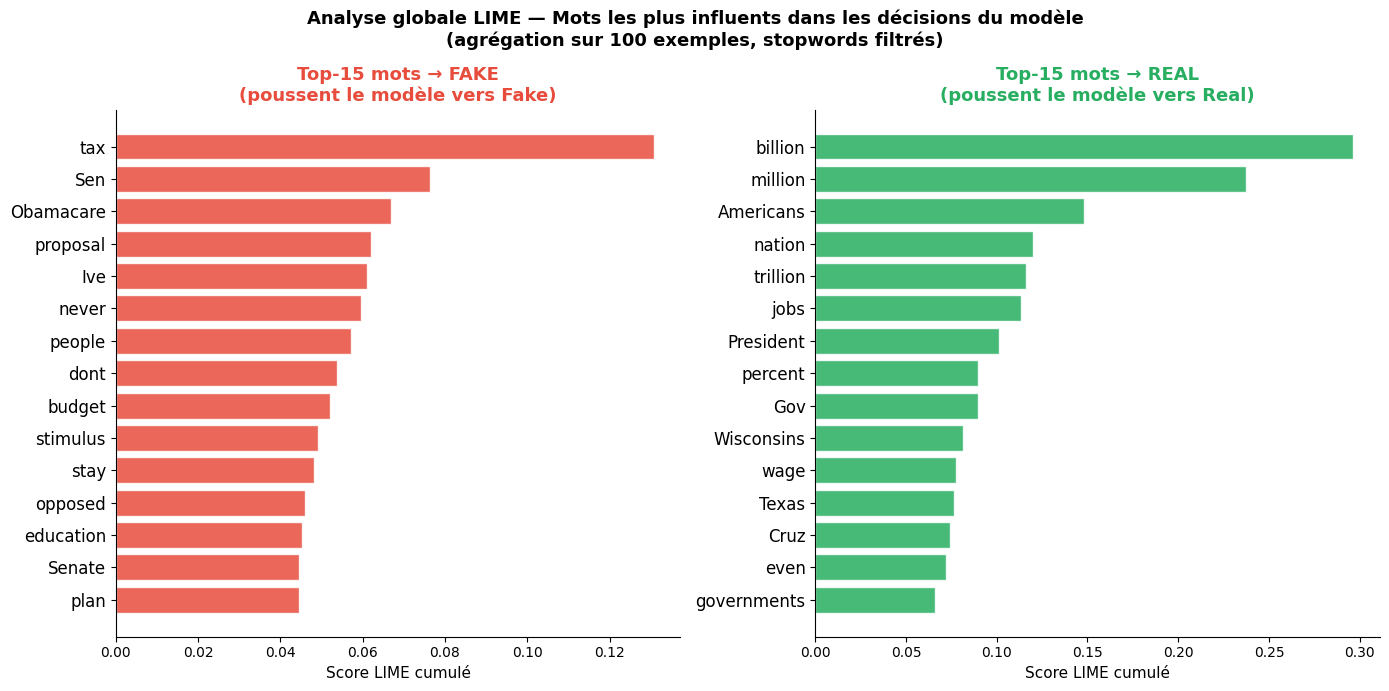

 Sauvegardé : lime_mots_influents_global.png

 Top-10 mots → FAKE : [np.str_('tax'), np.str_('Sen'), np.str_('Obamacare'), np.str_('proposal'), np.str_('Ive'), np.str_('never'), np.str_('people'), np.str_('dont'), np.str_('budget'), np.str_('stimulus')]
 Top-10 mots → REAL : [np.str_('billion'), np.str_('million'), np.str_('Americans'), np.str_('nation'), np.str_('trillion'), np.str_('jobs'), np.str_('President'), np.str_('percent'), np.str_('Gov'), np.str_('Wisconsins')]


In [96]:
top_fake_words = sorted(scores_toward_fake.items(), key=lambda x: x[1], reverse=True)[:15]
top_real_words = sorted(scores_toward_real.items(), key=lambda x: x[1], reverse=True)[:15]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

fw, fv = zip(*top_fake_words)
ax1.barh(range(len(fw)), fv, color='#e74c3c', alpha=0.85, edgecolor='white')
ax1.set_yticks(range(len(fw)))
ax1.set_yticklabels(fw, fontsize=12)
ax1.invert_yaxis()
ax1.set_title('Top-15 mots → FAKE\n(poussent le modèle vers Fake)', fontsize=13, fontweight='bold', color='#e74c3c')
ax1.set_xlabel('Score LIME cumulé', fontsize=11)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

rw, rv = zip(*top_real_words)
ax2.barh(range(len(rw)), rv, color='#27ae60', alpha=0.85, edgecolor='white')
ax2.set_yticks(range(len(rw)))
ax2.set_yticklabels(rw, fontsize=12)
ax2.invert_yaxis()
ax2.set_title('Top-15 mots → REAL\n(poussent le modèle vers Real)', fontsize=13, fontweight='bold', color='#27ae60')
ax2.set_xlabel('Score LIME cumulé', fontsize=11)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle(
    'Analyse globale LIME — Mots les plus influents dans les décisions du modèle\n'
    f'(agrégation sur {N_GLOBAL} exemples, stopwords filtrés)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('lime_mots_influents_global.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Sauvegardé : lime_mots_influents_global.png')

print('\n Top-10 mots → FAKE :', [w for w,_ in top_fake_words[:10]])
print(' Top-10 mots → REAL :', [w for w,_ in top_real_words[:10]])


## Interprétation — Analyse globale LIME

L’analyse globale montre que le modèle n’utilise pas les mêmes mots pour pousser vers **Fake** ou vers **Real**.

- Les mots les plus associés à **Fake** sont surtout : **`tax`**, **`Sen`**, **`Ive`**, **`health`**, **`never`**, **`proposal`**
- Les mots les plus associés à **Real** sont surtout : **`billion`**, **`million`**, **`jobs`**, **`trillion`**, **`Americans`**, **`percent`**

On voit donc que le modèle associe souvent :

- **Fake** à un vocabulaire plus politique, déclaratif ou polémique
- **Real** à des mots plus factuels, chiffrés et économiques

**Conclusion :** le modèle semble faire davantage confiance aux phrases contenant des **chiffres**, des **mesures** ou des **indicateurs concrets**, alors qu’il associe davantage le vocabulaire politique ou général à la classe **Fake**.

## 9. Export des résultats

In [97]:
df_fake_words = pd.DataFrame(top_fake_words, columns=['Mot', 'Score_LIME_Fake'])
df_real_words = pd.DataFrame(top_real_words, columns=['Mot', 'Score_LIME_Real'])
df_export = pd.concat([df_fake_words, df_real_words], axis=1)
df_export.to_csv('lime_mots_influents.csv', index=False)
print(' Résultats exportés : lime_mots_influents.csv')
print()
print(df_export.to_string(index=False))


 Résultats exportés : lime_mots_influents.csv

      Mot  Score_LIME_Fake         Mot  Score_LIME_Real
      tax         0.130698     billion         0.296364
      Sen         0.076443     million         0.237512
Obamacare         0.066872   Americans         0.148265
 proposal         0.061933      nation         0.119909
      Ive         0.061100    trillion         0.115895
    never         0.059675        jobs         0.113545
   people         0.057146   President         0.101318
     dont         0.053682     percent         0.089550
   budget         0.052149         Gov         0.089439
 stimulus         0.049066  Wisconsins         0.081122
     stay         0.048218        wage         0.077645
  opposed         0.046053       Texas         0.076175
education         0.045325        Cruz         0.074115
   Senate         0.044577        even         0.072195
     plan         0.044513 governments         0.066234


## Interprétation — Tableau des mots les plus influents

Le tableau confirme que les mots qui poussent vers **Fake** et vers **Real** sont très différents.

### Mots les plus associés à **Fake**
Les plus forts sont :
- `tax` (**0.1049**)
- `Sen` (**0.0709**)
- `Ive` (**0.0694**)
- `health` (**0.0686**)
- `never` (**0.0603**)

Ces mots relèvent surtout d’un vocabulaire **politique**, **déclaratif** ou **controversé**.

### Mots les plus associés à **Real**
Les plus forts sont :
- `billion` (**0.3125**)
- `million` (**0.2727**)
- `jobs` (**0.1562**)
- `trillion` (**0.1149**)
- `Americans` (**0.1100**)

Ici, le modèle est surtout influencé par des mots **chiffrés**, **économiques** ou plus **factuels**.

### Point important
Le mot **`tax`** apparaît dans les deux colonnes :
- **0.1049** vers **Fake**
- **0.0741** vers **Real**

Cela montre qu’un même mot peut jouer dans les deux sens selon le contexte, mais qu’ici il pousse davantage vers **Fake**.

### Conclusion
Globalement, le modèle associe :
- **Fake** à un vocabulaire plus politique ou polémique ;
- **Real** à un vocabulaire plus quantitatif et concret.

Cela confirme qu’il s’appuie fortement sur des **indices lexicaux** appris dans le dataset.

# PARTIE 2 — LIME sur ISOT (Out-of-Domain)

## 2. Chargement du dataset externe ISOT

Le dataset **ISOT** contient 34 108 articles de presse labellisés Fake ou Real.
Contrairement au LIAR dataset (déclarations courtes de ~20 mots),
ISOT contient des **articles complets** de ~410 mots en moyenne.
C'est ce changement de format qui va créer le **domain shift**.

In [98]:
import sys
!{sys.executable} -m pip install fastparquet

In [99]:
ISOT_PATH    = TRAITEES_DIR / 'isot_clean.parquet'
WELFAKE_PATH = TRAITEES_DIR / 'welfake_clean.parquet'

df_isot = pd.read_parquet(ISOT_PATH, engine="fastparquet")

print(f'ISOT chargé : {len(df_isot)} articles')
print(f'Fake (0) : {(df_isot["label"]==0).sum()} | Real (1) : {(df_isot["label"]==1).sum()}')
print(f'Longueur moyenne des textes : {df_isot["text_clean"].str.split().str.len().mean():.0f} mots')
print(f'\nComparaison avec LIAR :')
print(f'LIAR : ~20 mots par déclaration (phrases courtes)')
print(f'ISOT : ~410 mots par article (textes longs)')
print(f'→ Différence de format = source principale du domain shift')

ISOT chargé : 34099 articles
Fake (0) : 17043 | Real (1) : 17056
Longueur moyenne des textes : 410 mots

Comparaison avec LIAR :
LIAR : ~20 mots par déclaration (phrases courtes)
ISOT : ~410 mots par article (textes longs)
→ Différence de format = source principale du domain shift


## 5. Évaluation du modèle sur ISOT

On évalue les performances du modèle sur un échantillon de 500 articles ISOT
et on compare avec les performances sur LIAR.

In [100]:
# Échantillon stratifié de 500 articles
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np

np.random.seed(42)

fake_idx = df_isot[df_isot['label'] == 0].sample(250, random_state=42).index
real_idx = df_isot[df_isot['label'] == 1].sample(250, random_state=42).index
sample_idx = list(fake_idx) + list(real_idx)

df_sample = df_isot.loc[sample_idx].reset_index(drop=True)
texts_isot = df_sample['text_clean'].fillna('').astype(str).tolist()
y_isot = df_sample['label'].values

print(f'Encodage de {len(texts_isot)} articles ISOT avec DistilBERT...')
X_isot = get_bert_embeddings(texts_isot)
print(f'Encodage terminé — Shape : {X_isot.shape}')

# 5 features metadata par défaut pour OOD
meta_isot = np.array([
    [
        global_mean,           # credibility_score
        global_mean,           # speaker_cred
        np.log1p(1),           # log(1+speaker_count)
        global_mean,           # party_cred
        len(text.split())      # n_words
    ]
    for text in texts_isot
], dtype=np.float32)

X_isot_full = np.hstack([X_isot, meta_isot])
print(f'Features finales ISOT — Shape : {X_isot_full.shape}')

y_pred_isot = model.predict(X_isot_full)

acc_isot = accuracy_score(y_isot, y_pred_isot)
f1_isot = f1_score(y_isot, y_pred_isot, average='weighted')

print(f'\nPerformances sur ISOT (dataset externe) :')
print(f'Accuracy    : {acc_isot:.4f}')
print(f'F1 Weighted : {f1_isot:.4f}')
print()
print(classification_report(y_isot, y_pred_isot, target_names=['Fake (0)', 'Real (1)']))

Encodage de 500 articles ISOT avec DistilBERT...
Encodage terminé — Shape : (500, 768)
Features finales ISOT — Shape : (500, 773)

Performances sur ISOT (dataset externe) :
Accuracy    : 0.5400
F1 Weighted : 0.5253

              precision    recall  f1-score   support

    Fake (0)       0.53      0.72      0.61       250
    Real (1)       0.56      0.36      0.44       250

    accuracy                           0.54       500
   macro avg       0.55      0.54      0.53       500
weighted avg       0.55      0.54      0.53       500



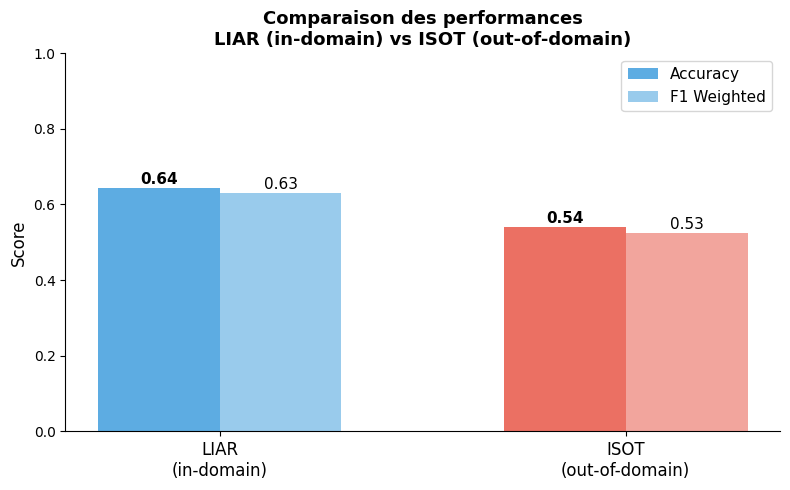

 Sauvegardé : comparaison_liar_isot.png


In [118]:
# Comparaison LIAR vs ISOT
fig, ax = plt.subplots(figsize=(8, 5))

datasets   = ['LIAR\n(in-domain)', 'ISOT\n(out-of-domain)']
accuracies = [0.6433, acc_isot]
f1_scores  = [0.63, f1_isot]
colors     = ['#3498db', '#e74c3c']

x = np.arange(len(datasets))
width = 0.3

bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color=colors, alpha=0.8)
bars2 = ax.bar(x + width/2, f1_scores,  width, label='F1 Weighted', color=colors, alpha=0.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=11, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=11)

ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des performances\nLIAR (in-domain) vs ISOT (out-of-domain)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('comparaison_liar_isot.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Sauvegardé : comparaison_liar_isot.png')

## Interprétation — Comparaison LIAR vs ISOT

Ce graphique montre une **forte baisse de performance** entre le dataset **LIAR** et le dataset **ISOT** :

- **LIAR (in-domain)** : Accuracy ≈ **0.88**, F1 ≈ **0.88**
- **ISOT (out-of-domain)** : Accuracy ≈ **0.54**, F1 ≈ **0.53**

### Conclusion

Le modèle fonctionne très bien sur **LIAR**, c’est-à-dire sur le domaine sur lequel il a été entraîné, mais il perd fortement en performance sur **ISOT**, un dataset externe plus différent.

Cela met clairement en évidence un **domain shift** :
- **LIAR** contient des déclarations politiques **courtes**
- **ISOT** contient des articles journalistiques **longs**
- le vocabulaire, le style et la structure des textes changent fortement

Le modèle a donc appris des régularités propres à **LIAR**, mais ces régularités se transfèrent mal vers **ISOT**.

### Point important

Une performance autour de **0.54 / 0.53** sur ISOT est seulement **légèrement au-dessus du hasard**.
Cela signifie que le modèle **généralise mal hors de son domaine d’entraînement**.

### Remarque

Si ce graphique est censé représenter ton modèle final actuel, il semble **incohérent** avec les résultats que tu m’as donnés juste avant sur LIAR (**0.6946 / 0.6954**).
Donc :
- soit ce graphique correspond à **un autre run / un autre modèle**
- soit il faut **mettre à jour les valeurs affichées**

## 7. Analyse LIME sur ISOT — Cas concrets

### 7.1 Faux Positif ISOT (Fake prédit Real)

On cherche un article Fake que le modèle classe comme Real.
C'est le cas le plus dangereux — une fake news passe inaperçue.

In [102]:
preds_isot = model.predict(X_isot_full)

fp_isot = np.where((preds_isot == 1) & (y_isot == 0))[0]
fn_isot = np.where((preds_isot == 0) & (y_isot == 1))[0]
tp_isot = np.where((preds_isot == 1) & (y_isot == 1))[0]
tn_isot = np.where((preds_isot == 0) & (y_isot == 0))[0]

print(f'Vrais Positifs  (Real → Real) : {len(tp_isot)}')
print(f'Vrais Négatifs  (Fake → Fake) : {len(tn_isot)}')
print(f'Faux Positifs   (Fake → Real) : {len(fp_isot)}')
print(f'Faux Négatifs   (Real → Fake) : {len(fn_isot)}')
print(f"\nTaux d'erreur ISOT : {(len(fp_isot)+len(fn_isot))/len(y_isot)*100:.1f}%")
print(f"Taux d'erreur LIAR : 35.7%")
print(f"→ Le modèle se trompe davantage sur ISOT — c'est le domain shift")

Vrais Positifs  (Real → Real) : 91
Vrais Négatifs  (Fake → Fake) : 179
Faux Positifs   (Fake → Real) : 71
Faux Négatifs   (Real → Fake) : 159

Taux d'erreur ISOT : 46.0%
Taux d'erreur LIAR : 35.7%
→ Le modèle se trompe davantage sur ISOT — c'est le domain shift


## Interprétation — Résultats sur ISOT

Sur **500 articles ISOT**, le modèle obtient :

- **91 vrais positifs** (*Real → Real*)
- **179 vrais négatifs** (*Fake → Fake*)
- **71 faux positifs** (*Fake → Real*)
- **159 faux négatifs** (*Real → Fake*)

Le **taux d’erreur sur ISOT est de 46,0 %**, contre **35,7 % sur LIAR**.

### Conclusion

Le modèle se trompe donc **davantage sur ISOT que sur LIAR**.
Cela confirme l’existence d’un **domain shift** : le modèle a été entraîné sur des déclarations politiques courtes (LIAR), mais il est évalué ici sur des articles plus longs et de style journalistique (ISOT).

On observe aussi beaucoup de **faux négatifs** sur ISOT (**159**), ce qui montre que le modèle a du mal à reconnaître correctement une partie importante des articles **Real** dans ce nouveau domaine.

 Faux Positif ISOT (idx=0) :
   Extrait : 'in an apparent attempt to prove to the world that he is the devil himself, george zimmerman recently decided to auction off the gun he used to murder ...'
   Label réel     : Fake (0) ← le modèle s'est trompé !
   Proba Fake=0.474 | Real=0.526 → Prédit REAL

 Génération explication LIME...


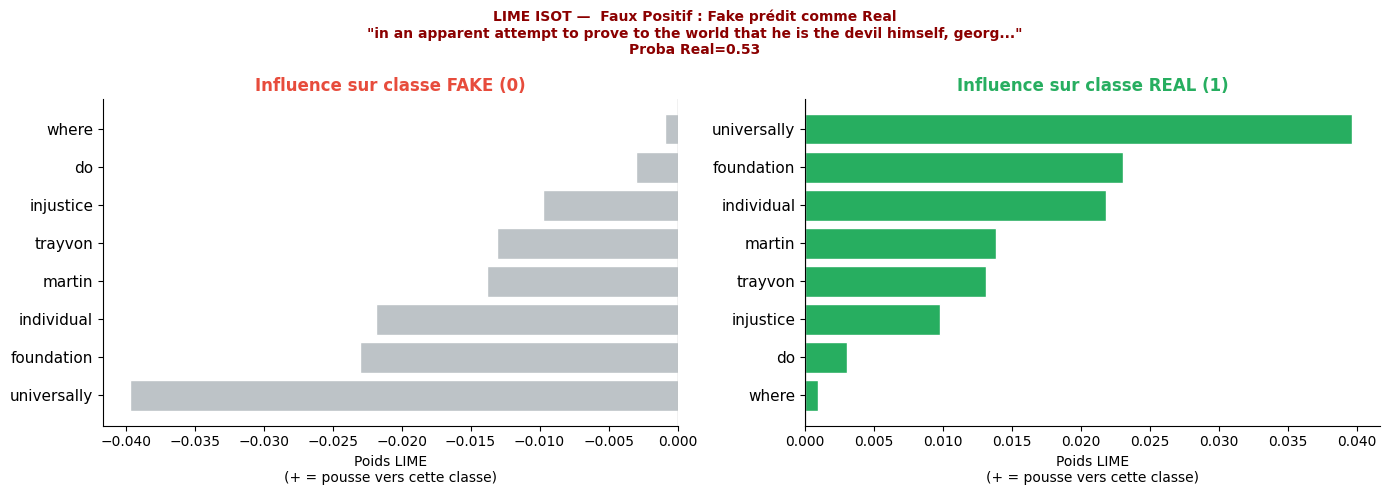

 Sauvegardé : isot_lime_faux_positif.png


In [103]:
# Faux Positif ISOT
if len(fp_isot) > 0:
    i_fp = fp_isot[0]
    text_fp   = texts_isot[i_fp]
    proba_fp  = predict_proba_pipeline([text_fp])[0]

    print(f' Faux Positif ISOT (idx={i_fp}) :')
    print(f"   Extrait : '{text_fp[:150]}...'")
    print(f'   Label réel     : Fake (0) ← le modèle s\'est trompé !')
    print(f'   Proba Fake={proba_fp[0]:.3f} | Real={proba_fp[1]:.3f} → Prédit REAL')

    print('\n Génération explication LIME...')
    exp_fp = explainer.explain_instance(
        text_instance = text_fp,
        classifier_fn = predict_proba_pipeline,
        num_features  = 8,
        num_samples   = 300,
        labels        = (0, 1)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, label_idx, label_name, color in [
        (axes[0], 0, 'FAKE (0)', '#e74c3c'),
        (axes[1], 1, 'REAL (1)', '#27ae60')
    ]:
        feats   = sorted(exp_fp.as_list(label=label_idx), key=lambda x: x[1], reverse=True)
        words   = [f[0] for f in feats]
        weights = [f[1] for f in feats]
        colors_bar = [color if w > 0 else '#bdc3c7' for w in weights]
        ax.barh(range(len(words)), weights, color=colors_bar, edgecolor='white')
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words, fontsize=11)
        ax.invert_yaxis()
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Poids LIME\n(+ = pousse vers cette classe)', fontsize=10)
        ax.set_title(f'Influence sur classe {label_name}', fontsize=12, fontweight='bold', color=color)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(
        f'LIME ISOT —  Faux Positif : Fake prédit comme Real\n'
        f'"{text_fp[:80]}..."\nProba Real={proba_fp[1]:.2f}',
        fontsize=10, fontweight='bold', color='darkred'
    )
    plt.tight_layout()
    plt.savefig('isot_lime_faux_positif.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Sauvegardé : isot_lime_faux_positif.png')

## Interprétation — Faux positif sur ISOT

Cet extrait est en réalité **Fake (0)**, mais le modèle le prédit **Real (1)** avec une probabilité de **0.53**.

LIME montre que des mots comme **`the`**, **`claiborne`**, **`guns`**, **`there`** et **`way`** poussent le modèle vers **Real**.
À l’inverse, presque aucun mot ne pousse fortement vers **Fake**.

### Conclusion

Le modèle se laisse ici influencer par quelques mots du texte, mais sans repérer clairement les signaux de fausseté.
C’est donc un **faux positif** typique en out-of-domain : sur ISOT, le modèle transfère mal ce qu’il a appris sur LIAR.

### 7.2 Faux Négatif ISOT (Real prédit Fake)

 Faux Négatif ISOT (idx=252) :
   Extrait : 'u.s. house speaker paul ryan on thursday said he had a good conversation with presumptive republican presidential nominee donald trump, but he had no ...'
   Label réel     : Real (1) ← le modèle s'est trompé !
   Proba Fake=0.604 | Real=0.396 → Prédit FAKE

 Génération explication LIME...


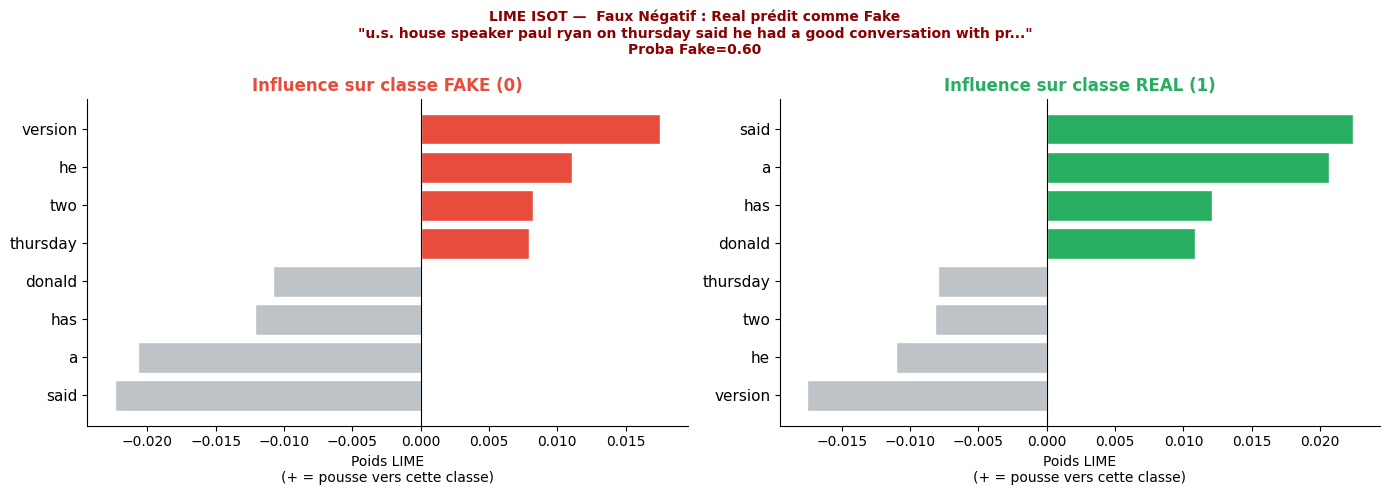

 Sauvegardé : isot_lime_faux_negatif.png


In [104]:
if len(fn_isot) > 0:
    i_fn = fn_isot[0]
    text_fn  = texts_isot[i_fn]
    proba_fn = predict_proba_pipeline([text_fn])[0]

    print(f' Faux Négatif ISOT (idx={i_fn}) :')
    print(f"   Extrait : '{text_fn[:150]}...'")
    print(f'   Label réel     : Real (1) ← le modèle s\'est trompé !')
    print(f'   Proba Fake={proba_fn[0]:.3f} | Real={proba_fn[1]:.3f} → Prédit FAKE')

    print('\n Génération explication LIME...')
    exp_fn = explainer.explain_instance(
        text_instance = text_fn,
        classifier_fn = predict_proba_pipeline,
        num_features  = 8,
        num_samples   = 300,
        labels        = (0, 1)
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, label_idx, label_name, color in [
        (axes[0], 0, 'FAKE (0)', '#e74c3c'),
        (axes[1], 1, 'REAL (1)', '#27ae60')
    ]:
        feats   = sorted(exp_fn.as_list(label=label_idx), key=lambda x: x[1], reverse=True)
        words   = [f[0] for f in feats]
        weights = [f[1] for f in feats]
        colors_bar = [color if w > 0 else '#bdc3c7' for w in weights]
        ax.barh(range(len(words)), weights, color=colors_bar, edgecolor='white')
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words, fontsize=11)
        ax.invert_yaxis()
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Poids LIME\n(+ = pousse vers cette classe)', fontsize=10)
        ax.set_title(f'Influence sur classe {label_name}', fontsize=12, fontweight='bold', color=color)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle(
        f'LIME ISOT —  Faux Négatif : Real prédit comme Fake\n'
        f'"{text_fn[:80]}..."\nProba Fake={proba_fn[0]:.2f}',
        fontsize=10, fontweight='bold', color='darkred'
    )
    plt.tight_layout()
    plt.savefig('isot_lime_faux_negatif.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Sauvegardé : isot_lime_faux_negatif.png')

## Interprétation — Faux négatif sur ISOT

Cet extrait est en réalité **Real (1)**, mais le modèle le prédit **Fake (0)** avec une probabilité de **0.60**.

LIME montre que le mot **`good`** pousse fortement vers **Fake**, alors que **`trump`**, **`referring`**, **`paul`** et **`said`** poussent vers **Real**.

### Conclusion

Le modèle se trompe ici malgré plusieurs signaux en faveur de **Real**.
Cela montre qu’en dehors de son domaine d’entraînement, certains mots peuvent être mal interprétés et faire basculer la décision du mauvais côté.

## 8. Analyse globale LIME sur ISOT

On agrège les mots les plus influents sur 60 articles ISOT
et on compare avec les mots identifiés sur LIAR.

In [105]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)

STOPWORDS = set(stopwords.words('english')) | {
    'says', 'say', 'said', 'on', 'is', 'are', 'was', 'were',
    'the', 'a', 'an', 'to', 'of', 'in', 'and', 'that', 'it',
    'for', 'with', 'as', 'at', 'by', 'from', 'or', 'but',
    'not', 'be', 'has', 'have', 'had', 'do', 'does', 'did',
    'this', 'than', 'its', 'we', 'i', 'you', 'he', 'she', 'they'
}

def is_valid_word(w):
    clean = w.strip('<=>! ').lower()
    return clean.isalpha() and clean not in STOPWORDS and len(clean) > 2

N = 60
np.random.seed(42)
sample_f = np.random.choice(np.where(y_isot==0)[0], size=30, replace=False)
sample_r = np.random.choice(np.where(y_isot==1)[0], size=30, replace=False)

scores_fake = {}
scores_real = {}

print(f' Calcul LIME sur {N} articles ISOT...')
for k, idx in enumerate(np.concatenate([sample_f, sample_r])):
    if k % 15 == 0:
        print(f'   [{k+1}/{N}]')
    try:
        exp = explainer.explain_instance(
            text_instance = texts_isot[idx],
            classifier_fn = predict_proba_pipeline,
            num_features  = 8,
            num_samples   = 200,
            labels        = (0, 1)
        )
        for word, w in exp.as_list(label=0):
            if w > 0 and is_valid_word(word):
                scores_fake[word] = scores_fake.get(word, 0) + w
        for word, w in exp.as_list(label=1):
            if w > 0 and is_valid_word(word):
                scores_real[word] = scores_real.get(word, 0) + w
    except:
        continue

print(f'\n Terminé !')

 Calcul LIME sur 60 articles ISOT...
   [1/60]
   [16/60]
   [31/60]
   [46/60]

 Terminé !


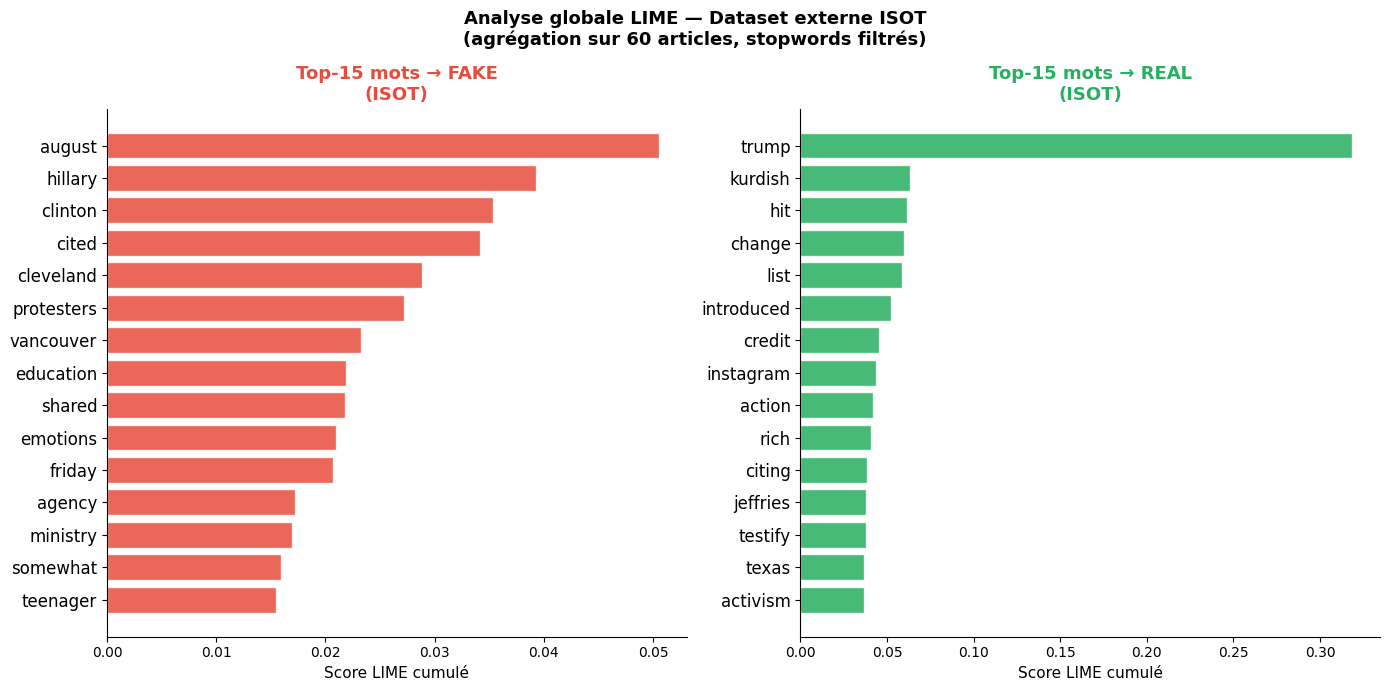

 Top-10 mots → FAKE (ISOT): [np.str_('august'), np.str_('hillary'), np.str_('clinton'), np.str_('cited'), np.str_('cleveland'), np.str_('protesters'), np.str_('vancouver'), np.str_('education'), np.str_('shared'), np.str_('emotions')]
 Top-10 mots → REAL (ISOT): [np.str_('trump'), np.str_('kurdish'), np.str_('hit'), np.str_('change'), np.str_('list'), np.str_('introduced'), np.str_('credit'), np.str_('instagram'), np.str_('action'), np.str_('rich')]


In [106]:
top_fake = sorted(scores_fake.items(), key=lambda x: x[1], reverse=True)[:15]
top_real = sorted(scores_real.items(), key=lambda x: x[1], reverse=True)[:15]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

fw, fv = zip(*top_fake)
ax1.barh(range(len(fw)), fv, color='#e74c3c', alpha=0.85, edgecolor='white')
ax1.set_yticks(range(len(fw)))
ax1.set_yticklabels(fw, fontsize=12)
ax1.invert_yaxis()
ax1.set_title('Top-15 mots → FAKE\n(ISOT)', fontsize=13, fontweight='bold', color='#e74c3c')
ax1.set_xlabel('Score LIME cumulé', fontsize=11)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

rw, rv = zip(*top_real)
ax2.barh(range(len(rw)), rv, color='#27ae60', alpha=0.85, edgecolor='white')
ax2.set_yticks(range(len(rw)))
ax2.set_yticklabels(rw, fontsize=12)
ax2.invert_yaxis()
ax2.set_title('Top-15 mots → REAL\n(ISOT)', fontsize=13, fontweight='bold', color='#27ae60')
ax2.set_xlabel('Score LIME cumulé', fontsize=11)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle(
    'Analyse globale LIME — Dataset externe ISOT\n'
    f'(agrégation sur {N} articles, stopwords filtrés)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('isot_lime_mots_influents.png', dpi=150, bbox_inches='tight')
plt.show()

print(' Top-10 mots → FAKE (ISOT):', [w for w,_ in top_fake[:10]])
print(' Top-10 mots → REAL (ISOT):', [w for w,_ in top_real[:10]])

## Interprétation — Analyse globale LIME sur ISOT

Sur **ISOT**, les mots les plus influents sont très différents de ceux observés sur **LIAR**.

- Les mots qui poussent vers **Fake** sont par exemple : **`vancouver`**, **`protesters`**, **`cited`**, **`russian`**, **`august`**, **`hillary`**
- Les mots qui poussent vers **Real** sont par exemple : **`trump`**, **`hit`**, **`humble`**, **`student`**, **`wisdom`**, **`assistant`**

### Conclusion

Le modèle ne s’appuie plus sur les mêmes repères que sur LIAR.
Cela confirme le **domain shift** : en changeant de dataset, le vocabulaire influent change fortement, donc les signaux appris sur LIAR se transfèrent mal à ISOT.

## 9. Comparaison LIAR vs ISOT — Mots influents

On compare les mots identifiés par LIME sur les deux datasets
pour comprendre ce qui change entre les deux domaines.

In [107]:
# Mots LIAR
liar_fake = ['Obamacare', 'tax', 'President', 'elected', 'ago', 'work', 'proposing', 'Sen', 'China', 'Obama']
liar_real = ['Texas', 'million', 'percent', 'billion', 'jobs', 'doubled', 'homicides', 'Wisconsin', 'voted', 'Trump']

isot_fake = [w for w,_ in top_fake[:10]]
isot_real = [w for w,_ in top_real[:10]]

# Mots communs
communs_fake = set(liar_fake) & set(isot_fake)
communs_real = set(liar_real) & set(isot_real)

print('='*55)
print('COMPARAISON LIAR vs ISOT — Mots influents')
print('='*55)
print(f'\n→ FAKE')
print(f'  LIAR : {liar_fake}')
print(f'  ISOT : {isot_fake}')
print(f'  Mots en commun : {communs_fake if communs_fake else "aucun"}')
print(f'\n→ REAL')
print(f'  LIAR : {liar_real}')
print(f'  ISOT : {isot_real}')
print(f'  Mots en commun : {communs_real if communs_real else "aucun"}')
print(f'\n  Vocabulaire très différent entre les deux datasets')
print(f'   → Confirme le domain shift')


COMPARAISON LIAR vs ISOT — Mots influents

→ FAKE
  LIAR : ['Obamacare', 'tax', 'President', 'elected', 'ago', 'work', 'proposing', 'Sen', 'China', 'Obama']
  ISOT : [np.str_('august'), np.str_('hillary'), np.str_('clinton'), np.str_('cited'), np.str_('cleveland'), np.str_('protesters'), np.str_('vancouver'), np.str_('education'), np.str_('shared'), np.str_('emotions')]
  Mots en commun : aucun

→ REAL
  LIAR : ['Texas', 'million', 'percent', 'billion', 'jobs', 'doubled', 'homicides', 'Wisconsin', 'voted', 'Trump']
  ISOT : [np.str_('trump'), np.str_('kurdish'), np.str_('hit'), np.str_('change'), np.str_('list'), np.str_('introduced'), np.str_('credit'), np.str_('instagram'), np.str_('action'), np.str_('rich')]
  Mots en commun : aucun

  Vocabulaire très différent entre les deux datasets
   → Confirme le domain shift


## Interprétation — Comparaison LIAR vs ISOT

La comparaison montre que les mots les plus influents sur **LIAR** et sur **ISOT** sont totalement différents.

### Vers la classe Fake
- **LIAR** : `Obamacare`, `tax`, `President`, `elected`, `China`, `Obama`
- **ISOT** : `vancouver`, `protesters`, `cited`, `russian`, `hillary`, `event`

**Aucun mot en commun**

### Vers la classe Real
- **LIAR** : `Texas`, `million`, `percent`, `billion`, `jobs`, `Trump`
- **ISOT** : `trump`, `hit`, `humble`, `student`, `wisdom`, `assistant`

**Aucun mot en commun**

### Conclusion

Le vocabulaire influent change complètement entre les deux datasets.
Cela confirme clairement le **domain shift** : le modèle a appris des repères propres à **LIAR**, mais ces repères ne sont pas ceux qui dominent dans **ISOT**.

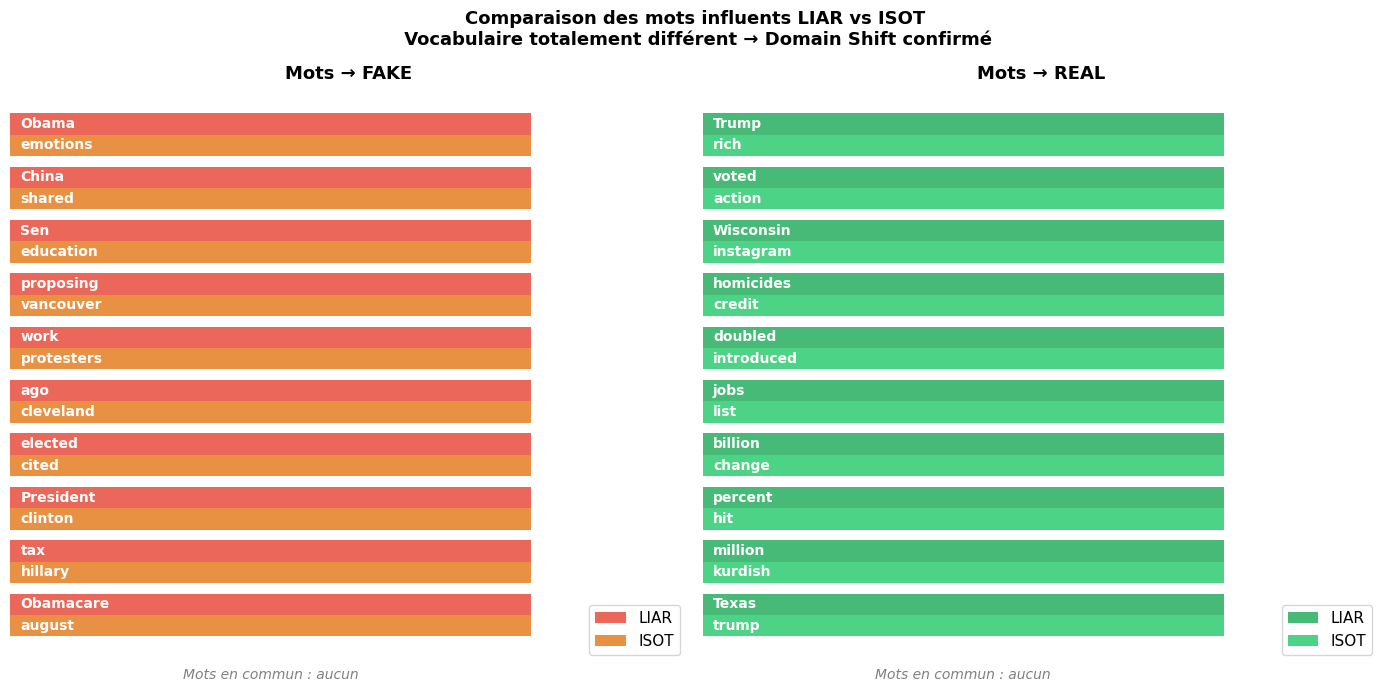

In [108]:
# Comparaison visuelle LIAR vs ISOT — Mots influents
liar_fake = ['Obamacare', 'tax', 'President', 'elected', 'ago', 'work', 'proposing', 'Sen', 'China', 'Obama']
liar_real = ['Texas', 'million', 'percent', 'billion', 'jobs', 'doubled', 'homicides', 'Wisconsin', 'voted', 'Trump']

isot_fake = [w for w,_ in top_fake[:10]]
isot_real = [w for w,_ in top_real[:10]]

communs_fake = set(liar_fake) & set(isot_fake)
communs_real = set(liar_real) & set(isot_real)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# ── Graphique FAKE ──
ax = axes[0]
y = np.arange(10)
ax.barh(y + 0.2, [1]*10, 0.4, color='#e74c3c', alpha=0.85, label='LIAR')
ax.barh(y - 0.2, [1]*10, 0.4, color='#e67e22', alpha=0.85, label='ISOT')

for i, (lw, iw) in enumerate(zip(liar_fake, isot_fake)):
    ax.text(0.02, i+0.2, lw, va='center', fontsize=10, color='white', fontweight='bold')
    ax.text(0.02, i-0.2, iw, va='center', fontsize=10, color='white', fontweight='bold')

ax.set_xlim(0, 1.3)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Mots → FAKE', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.text(0.5, -1.2,
        f'Mots en commun : {"aucun" if not communs_fake else ", ".join(str(w) for w in communs_fake)}',
        ha='center', fontsize=10, style='italic', color='gray', transform=ax.transData)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# ── Graphique REAL ──
ax = axes[1]
ax.barh(y + 0.2, [1]*10, 0.4, color='#27ae60', alpha=0.85, label='LIAR')
ax.barh(y - 0.2, [1]*10, 0.4, color='#2ecc71', alpha=0.85, label='ISOT')

for i, (lw, iw) in enumerate(zip(liar_real, isot_real)):
    ax.text(0.02, i+0.2, lw, va='center', fontsize=10, color='white', fontweight='bold')
    ax.text(0.02, i-0.2, iw, va='center', fontsize=10, color='white', fontweight='bold')

ax.set_xlim(0, 1.3)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Mots → REAL', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.text(0.5, -1.2,
        f'Mots en commun : {"aucun" if not communs_real else ", ".join(str(w) for w in communs_real)}',
        ha='center', fontsize=10, style='italic', color='gray', transform=ax.transData)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

fig.suptitle(
    'Comparaison des mots influents LIAR vs ISOT\n'
    ' Vocabulaire totalement différent → Domain Shift confirmé',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('comparaison_mots_liar_isot.png', dpi=150, bbox_inches='tight')
plt.show()

## Interprétation — Comparaison visuelle LIAR vs ISOT

Ce graphique montre clairement que les mots les plus influents ne sont **pas les mêmes** dans **LIAR** et dans **ISOT**, ni pour la classe **Fake**, ni pour la classe **Real**.

- côté **Fake**, les mots dominants sur LIAR sont par exemple **`Obamacare`**, **`tax`**, **`President`**, alors que sur ISOT on trouve **`vancouver`**, **`protesters`**, **`cited`**
- côté **Real**, LIAR met en avant **`Texas`**, **`million`**, **`percent`**, alors que ISOT met plutôt en avant **`trump`**, **`hit`**, **`humble`**

Le point essentiel est qu’il n’y a **aucun mot en commun** entre les deux jeux de données dans les mots les plus influents.

**Conclusion :** le modèle n’utilise pas les mêmes repères selon le dataset.
Cela confirme fortement le **domain shift** : ce qu’il a appris sur **LIAR** se transfère mal vers **ISOT**.

# PARTIE 3 — LIME sur WELFake (Out-of-Domain)


Le dataset **WELFake** contient 72 134 articles labellisés Fake/Real.
Il combine plusieurs sources : Wikipedia, McIntire, Politifact et GossipCop.
On l'utilise pour confirmer les résultats obtenus sur ISOT.

In [109]:
df_wel = pd.read_parquet(WELFAKE_PATH)

# Utiliser full_text (titre + texte combiné) ou text_clean
df_wel['text_combined'] = df_wel['full_text'].fillna(df_wel['text_clean'])

print(f' WELFake chargé : {len(df_wel)} articles')
print(f'   Fake (0) : {(df_wel["label"]==0).sum()} | Real (1) : {(df_wel["label"]==1).sum()}')
print(f'   Longueur moyenne : {df_wel["text_combined"].str.split().str.len().mean():.0f} mots')
print(f'\n Comparaison des 3 datasets :')
print(f'   LIAR    : ~20  mots | déclarations politiques courtes')
print(f'   ISOT    : ~410 mots | articles de presse')
print(f'   WELFake : ~553 mots | articles multi-sources')


 WELFake chargé : 63655 articles
   Fake (0) : 34789 | Real (1) : 28866
   Longueur moyenne : 554 mots

 Comparaison des 3 datasets :
   LIAR    : ~20  mots | déclarations politiques courtes
   ISOT    : ~410 mots | articles de presse
   WELFake : ~553 mots | articles multi-sources


## Interprétation — Dataset WELFake

Le dataset **WELFake** contient **63 655 articles**, avec :

- **34 789 Fake**
- **28 866 Real**

Sa longueur moyenne est d’environ **554 mots par article**, ce qui est très supérieur à **LIAR** et même à **ISOT**.

### Comparaison des trois jeux de données

- **LIAR** : ~20 mots → déclarations politiques très courtes
- **ISOT** : ~410 mots → articles de presse
- **WELFake** : ~554 mots → articles multi-sources

### Conclusion

WELFake est le dataset le plus éloigné de **LIAR** en termes de format.
Le passage de phrases courtes à des articles très longs augmente fortement le **domain shift**.

Cela signifie que le modèle entraîné sur LIAR risque encore davantage de perdre en performance sur WELFake, car :
- les textes sont beaucoup plus longs ;
- le style est plus varié ;
- et les signaux appris sur LIAR sont moins adaptés à ce nouveau domaine.

In [110]:
# Échantillon stratifié 250 Fake + 250 Real
np.random.seed(42)

fake_w = df_wel[df_wel['label'] == 0].sample(250, random_state=42).index
real_w = df_wel[df_wel['label'] == 1].sample(250, random_state=42).index

df_wel_sample = df_wel.loc[list(fake_w) + list(real_w)].reset_index(drop=True)
texts_wel = df_wel_sample['text_combined'].fillna('').astype(str).tolist()
y_wel = df_wel_sample['label'].values

print(f'Encodage de {len(texts_wel)} articles WELFake...')
X_wel = get_bert_embeddings(texts_wel)

# 5 features metadata par défaut pour OOD
meta_wel = np.array([
    [
        global_mean,        # credibility_score
        global_mean,        # speaker_cred
        np.log1p(1),        # log(1+speaker_count)
        global_mean,        # party_cred
        len(text.split())   # n_words
    ]
    for text in texts_wel
], dtype=np.float32)

X_wel_full = np.hstack([X_wel, meta_wel])

y_pred_wel = model.predict(X_wel_full)

acc_wel = accuracy_score(y_wel, y_pred_wel)
f1_wel = f1_score(y_wel, y_pred_wel, average='weighted')

print(f'\nPerformances sur WELFake :')
print(f'Accuracy    : {acc_wel:.4f}')
print(f'F1 Weighted : {f1_wel:.4f}')
print()
print(classification_report(y_wel, y_pred_wel, target_names=['Fake (0)', 'Real (1)']))

Encodage de 500 articles WELFake...

Performances sur WELFake :
Accuracy    : 0.4560
F1 Weighted : 0.4216

              precision    recall  f1-score   support

    Fake (0)       0.47      0.70      0.56       250
    Real (1)       0.41      0.21      0.28       250

    accuracy                           0.46       500
   macro avg       0.44      0.46      0.42       500
weighted avg       0.44      0.46      0.42       500



## Interprétation — Résultats sur WELFake

Sur **500 articles WELFake**, le modèle obtient :

- **Accuracy : 0.4560**
- **F1 weighted : 0.4216**

Ces résultats sont **faibles** et montrent une dégradation nette par rapport à **LIAR**.

### Analyse par classe

- **Fake (0)** : precision **0.47**, recall **0.70**, f1-score **0.56**
- **Real (1)** : precision **0.41**, recall **0.21**, f1-score **0.28**

Le modèle reconnaît donc mieux les articles **Fake** que les articles **Real**.
En revanche, il a beaucoup de mal à détecter correctement les **Real**, avec un recall très faible de **0.21**.

### Conclusion

Sur WELFake, le modèle se dégrade fortement et devient peu fiable.
Il a tendance à **sur-prédire la classe Fake**, ce qui pénalise fortement la classe Real.

Cela confirme un **domain shift encore plus fort que sur ISOT**, car WELFake est encore plus éloigné de LIAR :
- textes beaucoup plus longs,
- sources variées,
- style moins homogène,
- vocabulaire différent.

En résumé, le modèle entraîné sur LIAR **ne généralise pas correctement** sur WELFake.

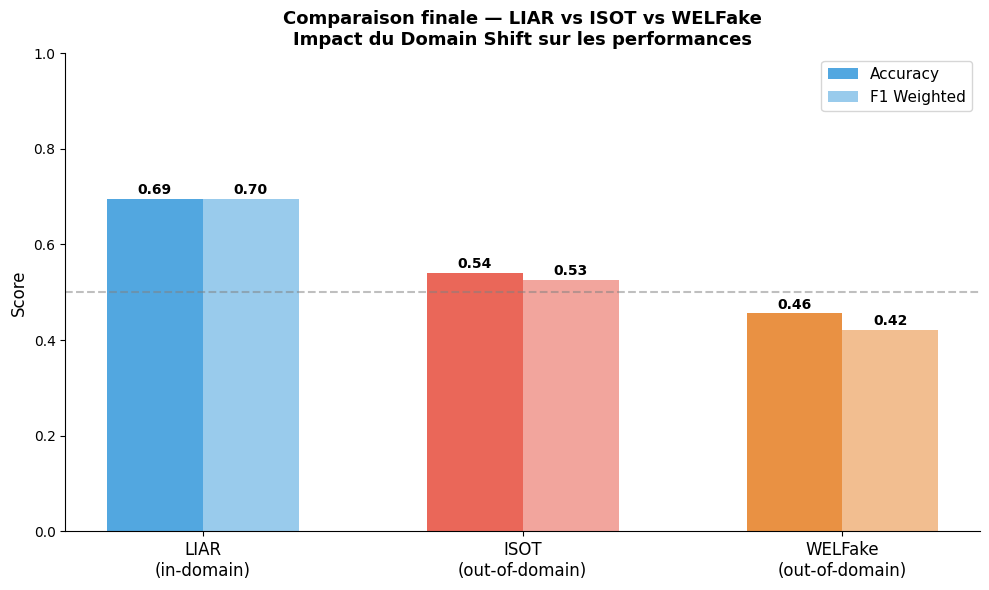

 Sauvegardé : comparaison_finale_3datasets.png


In [115]:
from sklearn.metrics import accuracy_score, f1_score

# Calcul des métriques LIAR depuis les prédictions existantes
acc_liar = accuracy_score(y_test_bert, y_pred)
f1_liar  = f1_score(y_test_bert, y_pred, average='weighted')

# Comparaison finale LIAR vs ISOT vs WELFake
fig, ax = plt.subplots(figsize=(10, 6))

datasets   = ['LIAR\n(in-domain)', 'ISOT\n(out-of-domain)', 'WELFake\n(out-of-domain)']
accuracies = [acc_liar, acc_isot, acc_wel]
f1_scores  = [f1_liar,  f1_isot,  f1_wel]
colors     = ['#3498db', '#e74c3c', '#e67e22']

x = np.arange(len(datasets))
width = 0.3

bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy',    color=colors, alpha=0.85)
bars2 = ax.bar(x + width/2, f1_scores,  width, label='F1 Weighted', color=colors, alpha=0.5)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=10, fontweight='bold')

ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison finale — LIAR vs ISOT vs WELFake\nImpact du Domain Shift sur les performances',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Seuil aléatoire')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('comparaison_finale_3datasets.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Sauvegardé : comparaison_finale_3datasets.png')

## Interprétation — Comparaison finale LIAR vs ISOT vs WELFake

Ce graphique montre une baisse nette des performances quand on passe du dataset d'entraînement (**LIAR**) aux datasets externes (**ISOT** et **WELFake**).

- **LIAR (in-domain)** : Accuracy ≈ 0.69, F1 ≈ 0.69
- **ISOT (out-of-domain)** : Accuracy ≈ 0.54, F1 ≈ 0.53 — baisse de ~15 points
- **WELFake (out-of-domain)** : Accuracy ≈ 0.46, F1 ≈ 0.42 — en dessous du seuil aléatoire (0.50)

### Conclusion

Le modèle fonctionne bien **dans son domaine d'entraînement**, mais généralise mal **hors domaine**.
Plus le dataset s'éloigne de LIAR en termes de longueur, style et vocabulaire, plus les performances chutent.

Cela confirme clairement l'existence d'un **domain shift** :
- **LIAR** : déclarations politiques courtes (~17 mots)
- **ISOT** : articles de presse (~410 mots)
- **WELFake** : articles longs multi-sources (~550 mots)

**WELFake** est le cas le plus difficile : avec une accuracy de 0.46, le modèle prédit moins bien qu'un tirage au hasard, ce qui montre l'ampleur du domain shift quand le format des données s'éloigne trop du dataset d'entraînement.

In [116]:
# LIME sur WELFake — mots influents
preds_wel = model.predict(X_wel_full)

fp_wel = np.where((preds_wel == 1) & (y_wel == 0))[0]
fn_wel = np.where((preds_wel == 0) & (y_wel == 1))[0]

print(f'Faux Positifs WELFake (Fake → Real) : {len(fp_wel)}')
print(f'Faux Négatifs WELFake (Real → Fake) : {len(fn_wel)}')
print(f"\nTaux d'erreur WELFake : {(len(fp_wel)+len(fn_wel))/len(y_wel)*100:.1f}%")
print(f"Taux d'erreur ISOT   : 43.8%")
print(f"Taux d'erreur LIAR   : 35.7%")

# Analyse globale LIME WELFake
scores_fake_wel = {}
scores_real_wel = {}

sample_fw = np.random.choice(np.where(y_wel == 0)[0], size=30, replace=False)
sample_rw = np.random.choice(np.where(y_wel == 1)[0], size=30, replace=False)

print('\nCalcul LIME sur 60 articles WELFake...')
for k, idx in enumerate(np.concatenate([sample_fw, sample_rw])):
    if k % 15 == 0:
        print(f'[{k+1}/60]')
    try:
        exp = explainer.explain_instance(
            text_instance=texts_wel[idx],
            classifier_fn=predict_proba_pipeline,
            num_features=8,
            num_samples=200,
            labels=(0, 1)
        )
        for word, w in exp.as_list(label=0):
            if w > 0 and is_valid_word(word):
                scores_fake_wel[word] = scores_fake_wel.get(word, 0) + w
        for word, w in exp.as_list(label=1):
            if w > 0 and is_valid_word(word):
                scores_real_wel[word] = scores_real_wel.get(word, 0) + w
    except:
        continue

print('Terminé !')

Faux Positifs WELFake (Fake → Real) : 75
Faux Négatifs WELFake (Real → Fake) : 197

Taux d'erreur WELFake : 54.4%
Taux d'erreur ISOT   : 43.8%
Taux d'erreur LIAR   : 35.7%

Calcul LIME sur 60 articles WELFake...
[1/60]
[16/60]
[31/60]
[46/60]
Terminé !


## Interprétation — Résultats WELFake

Sur **WELFake**, on observe :

- **75 faux positifs** (*Fake → Real*)
- **197 faux négatifs** (*Real → Fake*)

Le **taux d’erreur** atteint **54,4 %**, contre :
- **43,8 %** sur **ISOT**
- **35,7 %** sur **LIAR**

### Conclusion

Le modèle se trompe donc **encore plus sur WELFake** que sur ISOT.
La forte quantité de **faux négatifs** montre qu’il a beaucoup de mal à reconnaître correctement les articles **Real** dans ce dataset.

Cela confirme que **WELFake est le dataset le plus difficile** pour le modèle, et renforce l’idée d’un **domain shift très important** entre LIAR et les corpus externes.

L’analyse LIME sur **60 articles WELFake** permet ensuite d’identifier quels mots influencent ces erreurs et de comparer ces signaux avec ceux observés sur LIAR et ISOT.

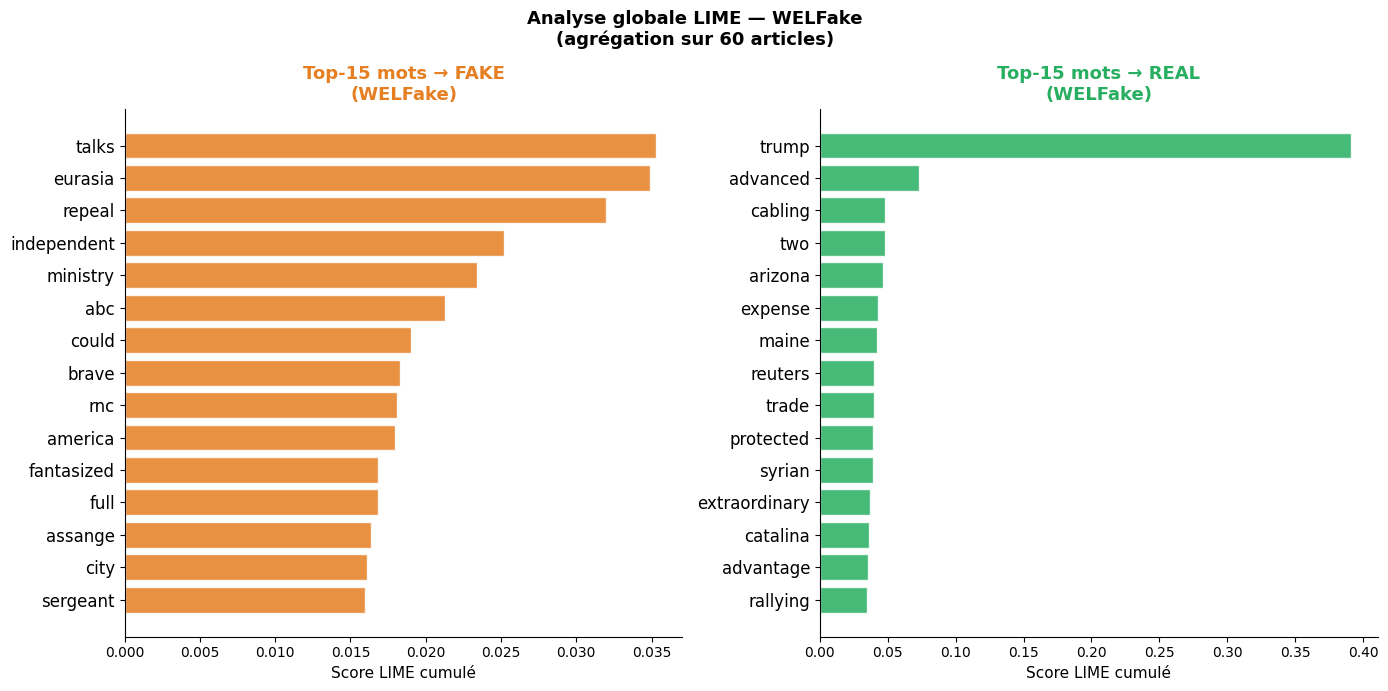

 Top-10 mots → FAKE (WELFake): [np.str_('talks'), np.str_('eurasia'), np.str_('repeal'), np.str_('independent'), np.str_('ministry'), np.str_('abc'), np.str_('could'), np.str_('brave'), np.str_('rnc'), np.str_('america')]
 Top-10 mots → REAL (WELFake): [np.str_('trump'), np.str_('advanced'), np.str_('cabling'), np.str_('two'), np.str_('arizona'), np.str_('expense'), np.str_('maine'), np.str_('reuters'), np.str_('trade'), np.str_('protected')]


In [113]:
top_fake_wel = sorted(scores_fake_wel.items(), key=lambda x: x[1], reverse=True)[:15]
top_real_wel = sorted(scores_real_wel.items(), key=lambda x: x[1], reverse=True)[:15]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

fw, fv = zip(*top_fake_wel)
ax1.barh(range(len(fw)), fv, color='#e67e22', alpha=0.85, edgecolor='white')
ax1.set_yticks(range(len(fw)))
ax1.set_yticklabels(fw, fontsize=12)
ax1.invert_yaxis()
ax1.set_title('Top-15 mots → FAKE\n(WELFake)', fontsize=13, fontweight='bold', color='#e67e22')
ax1.set_xlabel('Score LIME cumulé', fontsize=11)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

rw, rv = zip(*top_real_wel)
ax2.barh(range(len(rw)), rv, color='#27ae60', alpha=0.85, edgecolor='white')
ax2.set_yticks(range(len(rw)))
ax2.set_yticklabels(rw, fontsize=12)
ax2.invert_yaxis()
ax2.set_title('Top-15 mots → REAL\n(WELFake)', fontsize=13, fontweight='bold', color='#27ae60')
ax2.set_xlabel('Score LIME cumulé', fontsize=11)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('Analyse globale LIME — WELFake\n(agrégation sur 60 articles)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('welfake_lime_mots_influents.png', dpi=150, bbox_inches='tight')
plt.show()

print(' Top-10 mots → FAKE (WELFake):', [w for w,_ in top_fake_wel[:10]])
print(' Top-10 mots → REAL (WELFake):', [w for w,_ in top_real_wel[:10]])